In [3]:
### Preamples ###
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit

random.seed(13)

In [4]:
@njit
def heston_returns(V0, N, mu, theta, kappa, sigma_V, rho, h, n_sub):
    
    dt = h / n_sub
    sqrt_dt = dt ** 0.5
    c = (1 - rho ** 2) ** 0.5 
    
    returns = np.empty(N)
  
    Vt = V0
    log_ret = 0
    
    for n in range(N):
        log_ret = 0
        for _ in range(n_sub):
            z1 = np.random.normal(0, 1)
            z2 = np.random.normal(0, 1)
            
            dB1 = sqrt_dt * z1
            dB2 = sqrt_dt * (rho * z1 + c * z2) 
            
            Vt_pos = Vt if Vt > 0 else 0 # ensure variance is non-negative for the price update
            
            log_ret += (mu - 0.5 * Vt) * dt + Vt_pos ** 0.5 * dB1 # log return increment
            
            Vt = Vt_pos + kappa * (theta - Vt_pos)* dt + sigma_V * Vt_pos ** 0.5 * dB2  # variance process
            
        returns[n] = log_ret
        
    return returns 

In [5]:
def h_tilde(kappa, h):
    "h_tidle = (1 - exp(-kappa * h)) / kappa"
    return (1 - np.exp(-kappa * h)) / kappa

def lagm_cov_est(ret, m):
    
    N = len(ret)
    Ybar = np.mean(ret)
    
    cov = np.sum((ret[:N-m] - Ybar) * (ret[m:] - Ybar)) / (N - m)
    return cov

def estimate_kappa(ret, h, lag_M=10, verbose=False):
    N    = len(ret)
    lag1 = lagm_cov_est(ret, 1)

    if verbose:
        print(f"  lag1 = {lag1:+.6e}")

    kappa_sum   = 0.0
    valid_count = 0

    for m in range(2, lag_M + 1):
        lagm = lagm_cov_est(ret, m)

        if lagm == 0 or np.sign(lag1) != np.sign(lagm):
            continue

        ratio = lag1 / lagm
        if ratio <= 0 or not np.isfinite(np.log(ratio)):
            continue

        k_est = np.log(ratio) / ((m-1) * h)
        if not np.isfinite(k_est) or k_est <= 0:
            continue

        if verbose:
            print(f"  m={m:>3d}  lagm={lagm:+.4e}  ratio={ratio:.4f}  k_est={k_est:.4f}")

        kappa_sum   += k_est
        valid_count += 1

    if valid_count == 0:
        if verbose:
            print("  No valid lag ratios found — returning 0")
        return 0.0

    kappa = kappa_sum / valid_count

    if verbose:
        print(f"  κ̂ = {kappa:.6f}  ({valid_count}/{lag_M-1} valid terms)")

    return kappa

def estimate_moments(ret):
    n = len(ret)
    Ybar = np.mean(ret)
    mean = Ybar
    var = np.var(ret, ddof = 1)
    lag1 = lagm_cov_est(ret, 1) 
    lag2 = lagm_cov_est(ret, 2)

    y2 = ret[:-1]**2
    y2d = y2 - np.mean(y2)
    yn1d = ret[1:] - np.mean(ret[1:])
    cross = np.mean(y2d * yn1d)
    
    return np.array([mean, var, lag1, lag2, cross])

def moments(mu, theta, kappa, sigma_V, rho, h):
    """Returns first five moments of the log returns of the Heston model."""
    ht = h_tilde(kappa, h)
    ek = np.exp(-kappa * h)
    
    # First moment (mean), follows from Theorem 2.1
    
    mean = h * (mu  - 0.5 * theta)
    
    # Second moment (variance), follows from Theorem 2.2
    
    var = theta * (h - ht) * ( (sigma_V**2)/ (4 * (kappa ** 2)) 
                              - (rho * sigma_V) / kappa) + theta * h
    
    # Third moment (lag-1 autocovariance), follows from Theorem 2.3
    
    lag1 = (((ht ** 2) * theta * (sigma_V)) / 2 ) * ( (sigma_V) / (4 * kappa) - rho)
    
    # Fourth moment (lag-2 autocovariance), follows from Theorem 2.4
    
    lag2 = ek * lag1
    
    
    # Fifth moment (Cross variance bewteen squared retursn and future returns),
    # follows from Theorem 2.5
    
    term1 = ((theta * (sigma_V ** 4) / ( 8 * kappa **3))) * ht * (h * ek - ht)
    
    term2 = ht**2 * ((theta * sigma_V ** 2) / (4 * kappa) * mu * h
                     - (theta ** 2 * sigma_V ** 2) / (8 * kappa) * h
                     - (theta * sigma_V ** 2 ) / (4 * kappa))
    
    term3  = (-rho * sigma_V / 2 * ht) * (
        (3 * sigma_V**2 / (2 * kappa**2) - 2 * rho * sigma_V / kappa)
        * theta * (h * ek - ht)
        + (2 * mu * theta - theta**2) * h * ht
)
    
    cross = term1 + term2 - term3
    
    return mean, var, lag1, lag2, cross

In [6]:
def estimate_heston_from_returns(ret, h, verbose=False, fallback=True):

    samp                                    = estimate_moments(ret)
    mean_e, var_e, lag1_e, lag2_e, cross_e = samp

    kappa = estimate_kappa(ret, h, lag_M=10, verbose = verbose)
    if not np.isfinite(kappa) or kappa <= 0:
        raise ValueError(f"Invalid kappa = {kappa}")

    # Cap kappa at economically plausible range
    kappa = np.clip(kappa, 0.01, 20.0)

    ht = (1 - np.exp(-kappa*h)) / kappa
    ek = np.exp(-kappa*h)
    dh = h*ek - ht

    theta = var_e/h - (2*(h-ht)/(h*kappa*ht**2))*lag1_e
    if not np.isfinite(theta) or theta <= 0:
        theta = var_e/h   # fallback
    theta = np.clip(theta, 1e-6, 2.0)   # cap at 141% annual vol

    mu = mean_e/h + theta/2

    num      = (4*kappa*mean_e + (8*dh/(theta*ht**3))*lag1_e
                - 2*kappa*cross_e/lag1_e)
    den      = theta*ht**2/(2*lag1_e) - dh/(kappa*ht)
    sigma_sq = num/den if abs(den) > 1e-14 else -1

    if not np.isfinite(sigma_sq) or sigma_sq <= 0:
        if fallback:
            var_y2   = np.var(ret**2, ddof=1)
            sigma_sq = max(2*kappa*var_y2/(theta**2*h**2), 1e-8)
        else:
            raise ValueError(f"sigma_sq = {sigma_sq:.4e} negative")

    # Cap sigma_V at economically plausible range
    sigma_V = np.clip(sigma_sq**0.5, 1e-4, 2.0)

    rho = sigma_V/(4*kappa) - (2/(theta*sigma_V*ht**2))*lag1_e
    if not np.isfinite(rho):
        if fallback:
            rho = np.corrcoef(np.abs(ret[:-1]), -ret[1:])[0, 1]
    rho = np.clip(rho, -0.999, 0.999)

    if verbose:
        print(f"  κ̂    = {kappa:.4f}")
        print(f"  θ̂    = {theta:.4f}")
        print(f"  μ̂    = {mu:.4f}")
        print(f"  σ̂_V  = {sigma_V:.6f}")
        print(f"  ρ̂    = {rho:.6f}")

    return {'mu': mu, 'theta': theta, 'kappa': kappa,
            'sigma_V': sigma_V, 'rho': rho}

In [37]:
def goodness_of_fit_test(ret_real, h, n_boot=200):

    # Estimate and validate
    est  = estimate_heston_from_returns(ret_real, h, verbose=False)
    samp = estimate_moments(ret_real)

    # Guard: check all parameters are finite
    for k, v in est.items():
        if not np.isfinite(v):
            raise ValueError(
                f"Parameter {k} = {v} is not finite. "
                f"Estimation failed on this data — check sample size and frequency."
            )

    N     = len(ret_real)
    n_sub = int(20)
    V0    = float(est['theta'])

    print(f"Fitted parameters:")
    for k, v in est.items():
        print(f"  {k:<10s} = {v:.4f}")
    print(f"\nSimulating {n_boot} paths of N={N:,} …")

    boot_moments = []
    failed       = 0

    for b in range(n_boot):
        try:
            ret_sim = heston_returns(
                V0, int(N),
                float(est['mu']), float(est['theta']),
                float(est['kappa']), float(est['sigma_V']),
                float(est['rho']), float(h), n_sub
            )
            # Guard: check simulated returns are finite
            if not np.all(np.isfinite(ret_sim)):
                failed += 1
                continue
            m = estimate_moments(ret_sim)
            if np.all(np.isfinite(m)):
                boot_moments.append(m)
            else:
                failed += 1
        except Exception:
            failed += 1

        if (b+1) % 50 == 0:
            print(f"  {b+1}/{n_boot}  failed: {failed}")

    if len(boot_moments) == 0:
        raise ValueError("All bootstrap replications failed.")

    boot_moments = np.array(boot_moments)
    names        = ['Mean', 'Variance', 'Lag-1', 'Lag-2', 'Cross-Cov']

    print(f"\nGoodness of Fit — {len(boot_moments)} valid replications")
    print(f"{'Moment':<20s}  {'Empirical':>12s}  {'Boot Mean':>12s}  "
          f"{'Boot Std':>10s}  {'p-value':>10s}  {'Adequate?':>10s}")
    print("-" * 78)

    for i, name in enumerate(names):
        emp    = samp[i]
        b_mean = np.nanmean(boot_moments[:, i])
        b_std  = np.nanstd(boot_moments[:, i])
        if not np.isfinite(emp) or b_std == 0:
            print(f"  {name:<18s}  {'nan':>12s}  {'nan':>12s}  "
                  f"{'nan':>10s}  {'nan':>10s}  {'—':>10s}")
            continue
        p_val = 2 * min(
            np.mean(boot_moments[:, i] >= emp),
            np.mean(boot_moments[:, i] <= emp)
        )
        ok = '✓' if p_val >= 0.05 else '✗ misspecified'
        print(f"  {name:<18s}  {emp:>12.4e}  {b_mean:>12.4e}  "
              f"{b_std:>10.4e}  {p_val:>10.3f}  {ok:>10s}")

    return boot_moments

In [42]:
def goodness_of_fit_test_robust(ret_real, h, n_boot=200, 
                                 moments_to_test=None):
    """
    Robust GoF test that:
    1. Uses Bonferroni correction for multiple testing
    2. Allows restricting to well-identified moments
    3. Reports individual and joint p-values
    
    moments_to_test: list of indices to test, e.g. [0,1] for mean+var only
                     None = test all five
    """
    if moments_to_test is None:
        moments_to_test = [0, 1, 2, 3, 4]

    n_test = len(moments_to_test)
    alpha  = 0.05 / n_test   # Bonferroni correction

    est  = estimate_heston_from_returns(ret_real, h, verbose=False)
    samp = estimate_moments(ret_real)
    N    = len(ret_real)
    V0   = float(est['theta'])

    # Check all parameters are finite
    for k, v in est.items():
        if not np.isfinite(v):
            raise ValueError(f"Parameter {k} = {v} not finite.")

    boot_moments = []
    failed = 0
    for b in range(n_boot):
        try:
            ret_sim = heston_returns(V0, int(N),
                                     float(est['mu']),   float(est['theta']),
                                     float(est['kappa']),float(est['sigma_V']),
                                     float(est['rho']),  float(h), int(20))
            if np.all(np.isfinite(ret_sim)):
                m = estimate_moments(ret_sim)
                if np.all(np.isfinite(m)):
                    boot_moments.append(m)
        except Exception:
            failed += 1

    if len(boot_moments) < 10:
        raise ValueError("Too few valid bootstrap replications.")

    boot_moments = np.array(boot_moments)
    names_all    = ['Mean', 'Variance', 'Lag-1', 'Lag-2', 'Cross-Cov']

    print(f"\nGoF Test  (Bonferroni α = {alpha:.4f} per moment, "
          f"testing {n_test} moments)")
    print(f"{'Moment':<20s}  {'Empirical':>12s}  {'Boot Mean':>12s}  "
          f"{'Boot Std':>10s}  {'p-value':>10s}  {'Adequate?':>10s}")
    print("-" * 80)

    any_reject = False
    for i in moments_to_test:
        emp    = samp[i]
        b_mean = np.nanmean(boot_moments[:, i])
        b_std  = np.nanstd(boot_moments[:, i])
        if b_std == 0 or not np.isfinite(emp):
            continue
        p_val  = 2 * min(np.mean(boot_moments[:,i] >= emp),
                         np.mean(boot_moments[:,i] <= emp))
        ok     = '✓' if p_val >= alpha else '✗ misspecified'
        if p_val < alpha:
            any_reject = True
        print(f"  {names_all[i]:<18s}  {emp:>12.4e}  {b_mean:>12.4e}  "
              f"{b_std:>10.4e}  {p_val:>10.3f}  {ok:>10s}")

    print(f"\n  Joint conclusion: "
          f"{'H0 rejected — Heston misspecified' if any_reject else 'H0 not rejected — Heston adequate'}")

    return boot_moments

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

def load_real_data(ticker, start, end, freq='monthly'):
    """
    Robustly loads price data and computes returns.
    Uses proper resampling instead of naive slicing.
    """
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)

    prices = raw['Close'].dropna()

    if freq == 'monthly':
        prices_agg = prices.resample('ME').last().dropna()
        h          = 21 / 252
    elif freq == 'weekly':
        prices_agg = prices.resample('W-FRI').last().dropna()
        h          = 5 / 252
    else:
        prices_agg = prices
        h          = 1 / 252

    ret = np.diff(np.log(prices_agg.values))

    ret = ret[np.isfinite(ret)]

    print(f"{ticker} ({freq}): {len(prices_agg):,} prices → "
          f"{len(ret):,} returns")
    print(f"  NaN in ret: {np.isnan(ret).sum()}")
    print(f"  Ann. return: {np.mean(ret)*(252/21)*100:.2f}%")
    print(f"  Ann. vol   : {np.std(ret)*np.sqrt(252/21)*100:.2f}%")

    return ret, h


def run_real_data_analysis(ticker, start, end):
    """
    Full pipeline: load → estimate → goodness of fit test.
    """
    print(f"\n{'='*60}")
    print(f"Ticker: {ticker}  ({start} to {end})")
    print(f"{'='*60}")

    ret, h = load_real_data(ticker, start, end, freq='monthly')

    if len(ret) < 50:
        print(f"  Too few observations ({len(ret)}) — skipping.")
        return None

    # Estimate
    print(f"\nEstimating Heston parameters …")
    try:
        est = estimate_heston_from_returns(ret, h, verbose=False)
        ann_vol  = np.sqrt(abs(est['theta'])) * 100
        halflife = np.log(2) / est['kappa'] * 252 if est['kappa'] > 0 else np.inf
        print(f"  μ       = {est['mu']:.4f}  (ann. drift = {(est['mu'] - 0.5*est['theta']) * 100:.2f}% )")
        print(f"  θ       = {est['theta']:.4f}  (implied vol ≈ {ann_vol:.1f}%)")
        print(f"  κ       = {est['kappa']:.4f}  (half-life ≈ {halflife:.0f} days)")
        print(f"  σ_V     = {est['sigma_V']:.4f}")
        print(f"  ρ       = {est['rho']:.4f}")
        feller = 2*est['kappa']*est['theta'] >= est['sigma_V']**2
        print(f"  Feller  : {'✓' if feller else '✗'}")

        # Goodness of fit
        print(f"\nRunning goodness of fit test …")
        boot = goodness_of_fit_test_robust(ret, h=h, n_boot=200)
        return {'est': est, 'boot': boot}

    except Exception as ex:
        print(f"  Estimation failed: {ex}")
        return None


# ── Run ────────────────────────────────────────────────────────────────────────
for ticker in ['SPY', 'GLD', 'TLT']:
    run_real_data_analysis(ticker, start='2005-01-01', end='2024-01-01')


Ticker: SPY  (2005-01-01 to 2024-01-01)
SPY (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 9.28%
  Ann. vol   : 15.27%

Estimating Heston parameters …
  μ       = 0.1042  (ann. drift = 9.28% )
  θ       = 0.0229  (implied vol ≈ 15.1%)
  κ       = 0.1457  (half-life ≈ 1199 days)
  σ_V     = 0.9724
  ρ       = 0.9990
  Feller  : ✗

Running goodness of fit test …

GoF Test  (Bonferroni α = 0.0100 per moment, testing 5 moments)
Moment                   Empirical     Boot Mean    Boot Std     p-value   Adequate?
--------------------------------------------------------------------------------
  Mean                  7.7339e-03    2.4891e-03  9.0467e-03       0.060           ✓
  Variance              1.9506e-03    1.1928e-02  3.1477e-02       0.730           ✓
  Lag-1                 4.5183e-05   -2.0736e-04  1.9414e-03       0.680           ✓
  Lag-2                -1.4676e-04   -2.6028e-05  3.2267e-03       0.770           ✓
  Cross-Cov             1.4826e-06   -1.0474e

  SPY: 228 monthly prices, 227 returns
  GLD: 228 monthly prices, 227 returns
  TLT: 228 monthly prices, 227 returns

TABLE 1 — Descriptive Statistics (Monthly Log Returns)

Statistic                    SPY         GLD         TLT
--------------------------------------------------------

Statistic                      SPY         GLD         TLT
----------------------------------------------------------
  N                            227         227         227
  Ann. Return (%)             9.28        7.98        3.54
  Ann. Volatility (%)        15.30       16.82       13.82
  Min Return (%)            -18.05      -17.60      -14.01
  Max Return (%)             11.95       12.03       13.40
  Skewness                 -0.7619     -0.1150      0.2764
  Excess Kurtosis           1.5201      0.4258      1.1976
  JB Statistic               43.82        2.22       16.46
  JB p-value                0.0000      0.3304      0.0003
  LB²(12) p-value           0.0000      0.1135      0.0000

TA

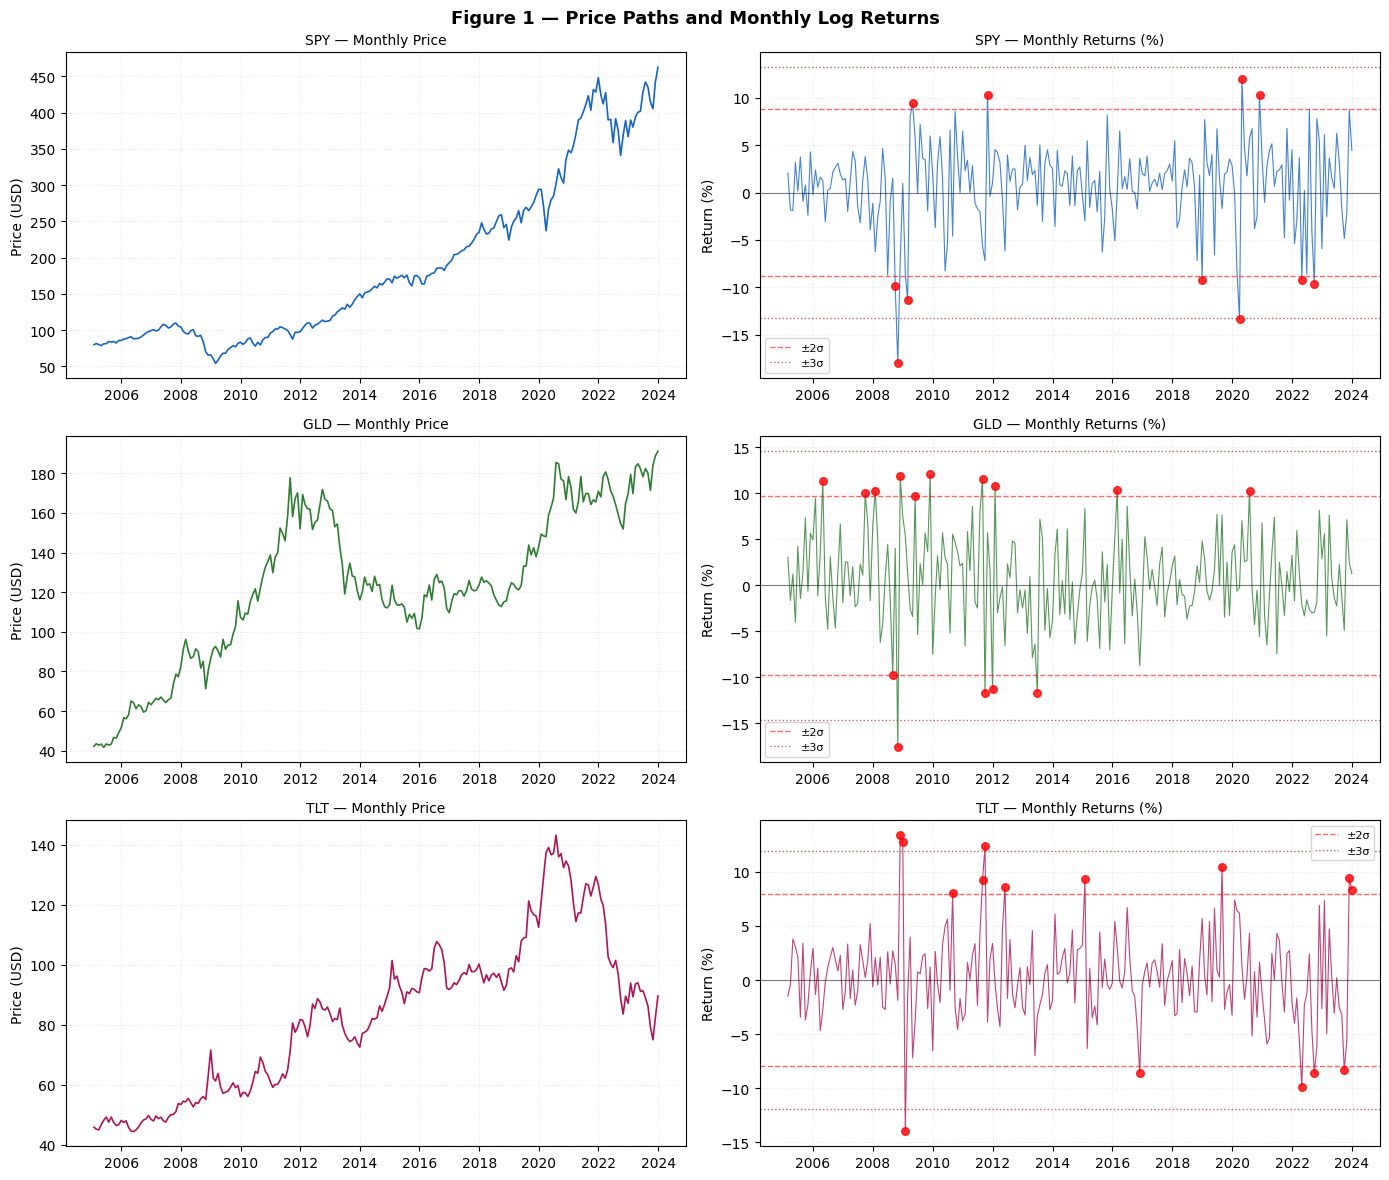

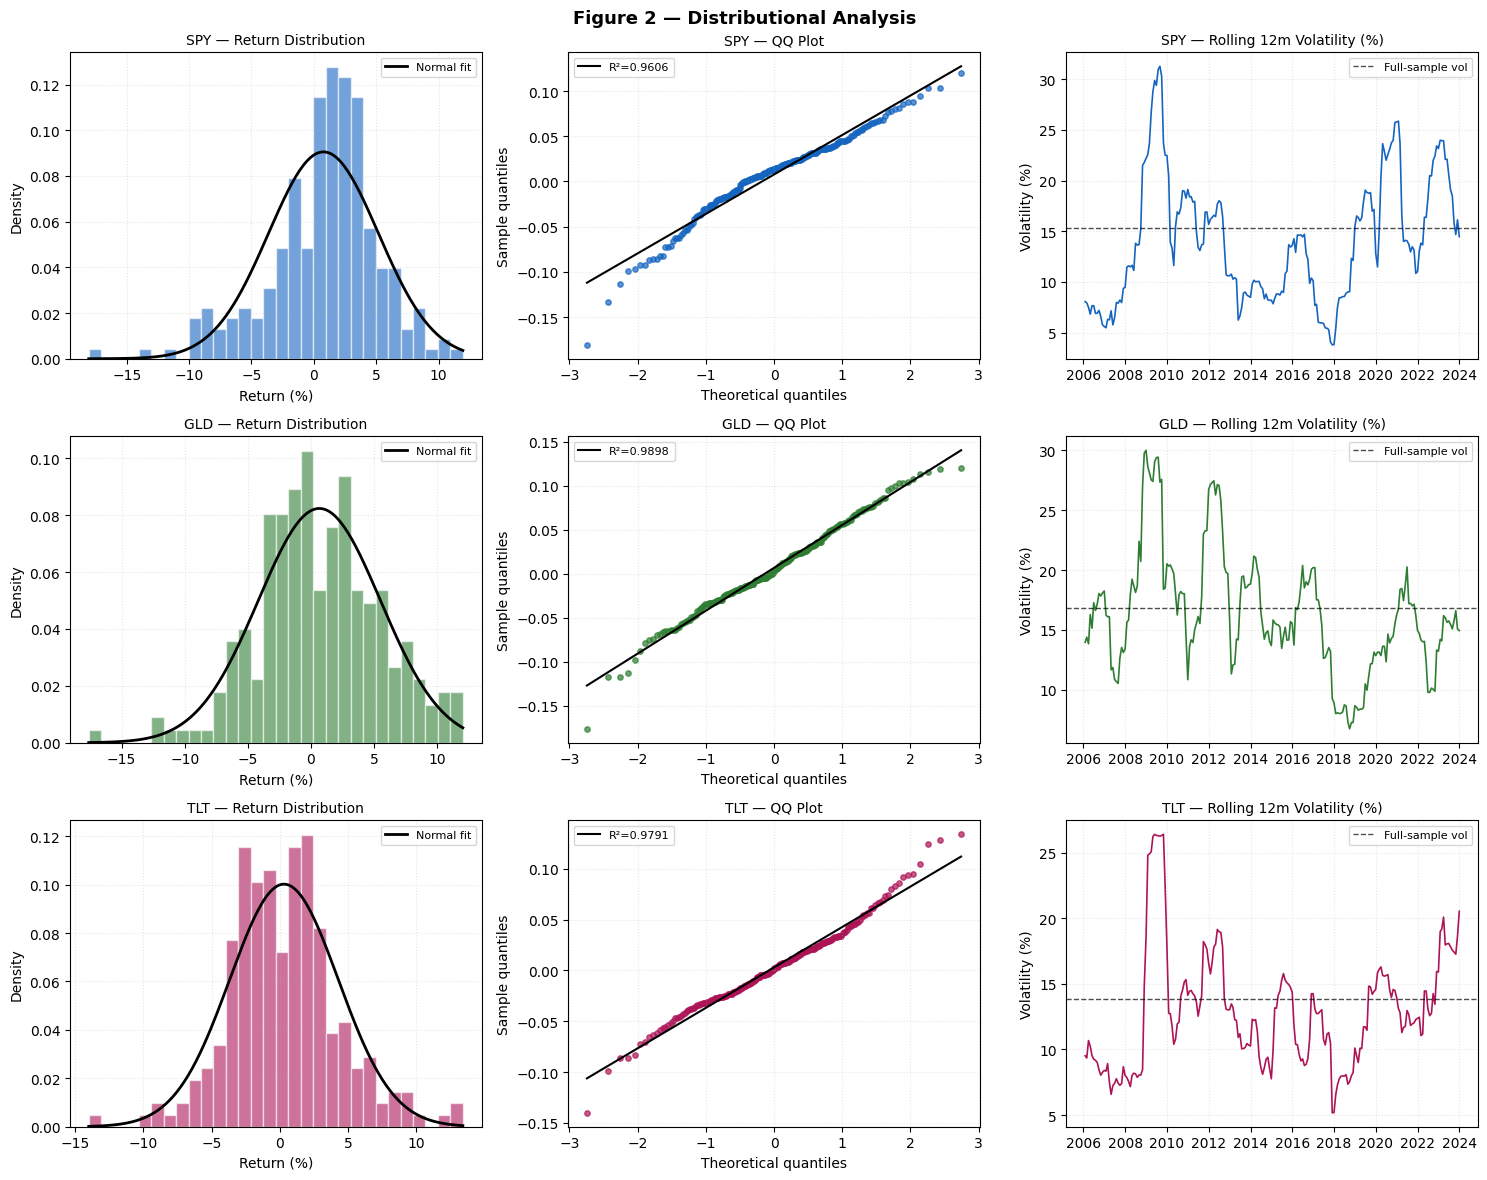

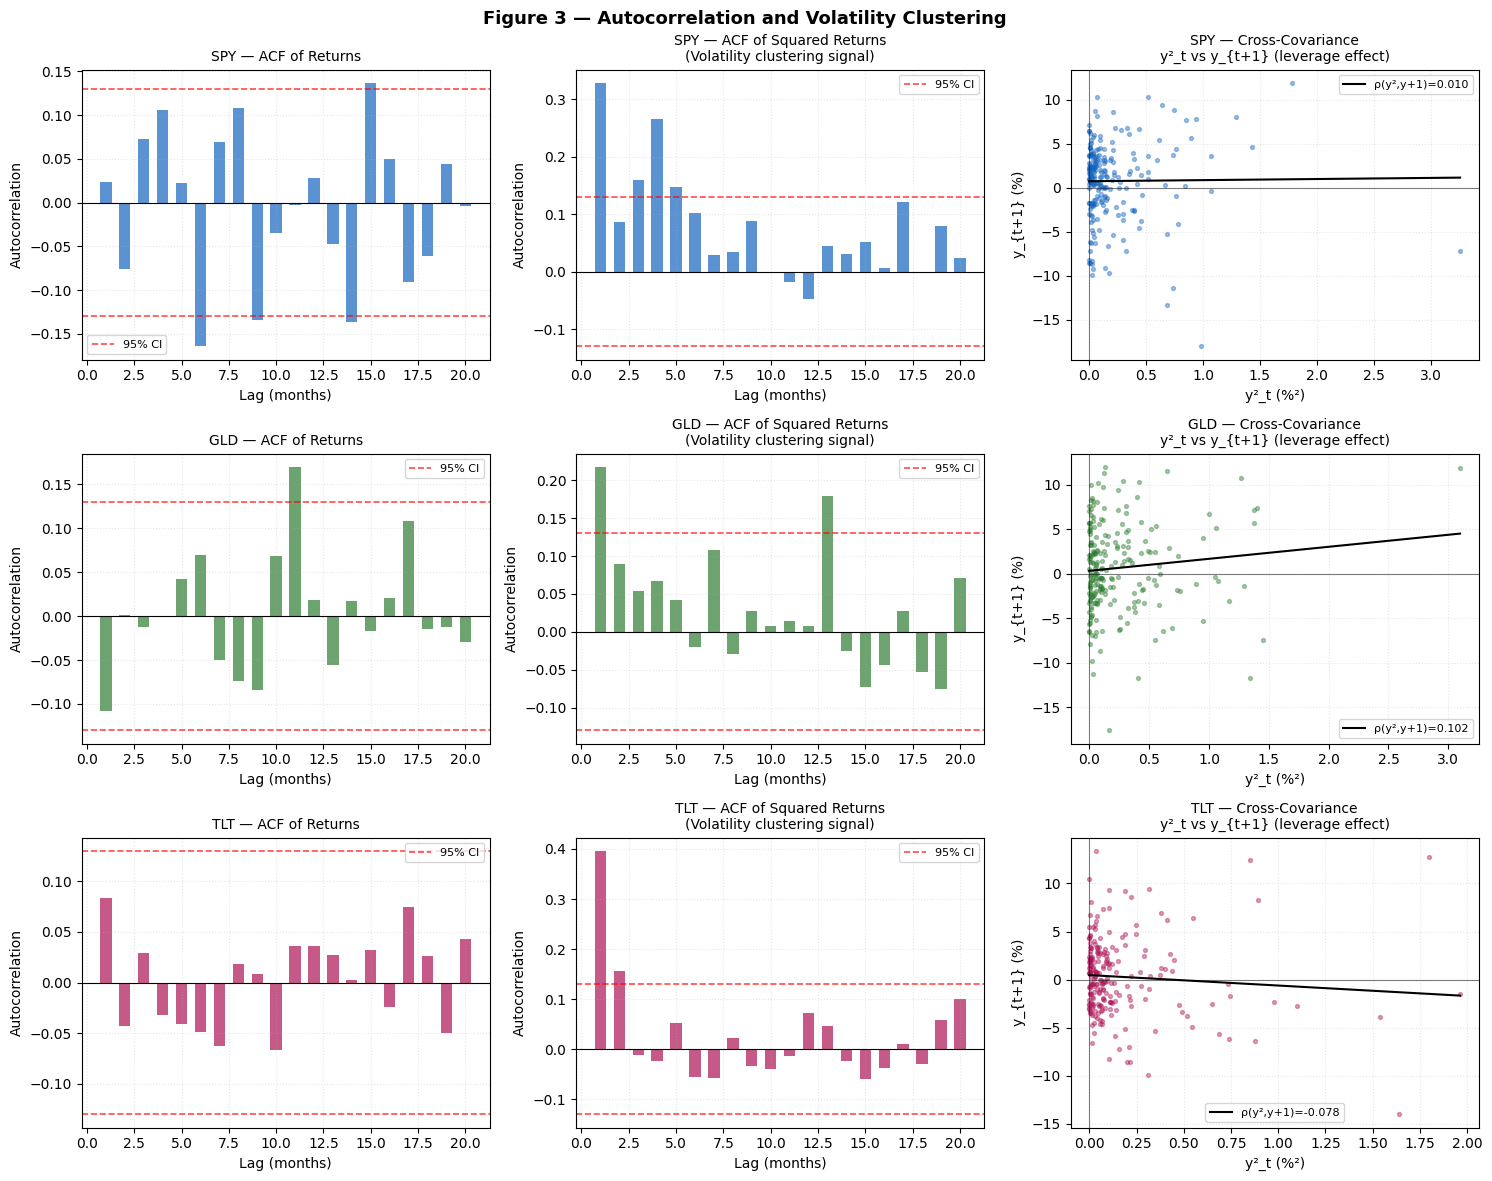

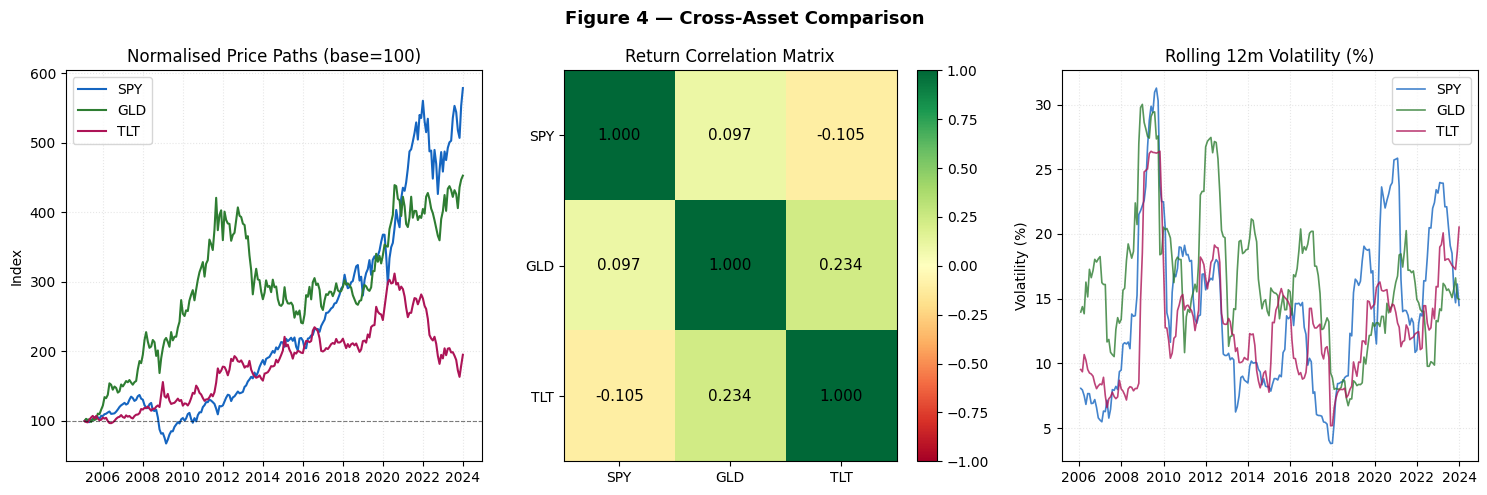


TABLE 4 — Empirical Moments (inputs to MM estimator)

Moment                              SPY           GLD           TLT
-------------------------------------------------------------------
  Mean return (×10⁻³)            7.7339        6.6532        2.9481
  Variance (×10⁻³)               1.9506        2.3575        1.5921
  Lag-1 autocov (×10⁻⁵)          4.5182      -25.4807       13.1156
  Lag-2 autocov (×10⁻⁵)        -14.6761        0.1764       -6.7150
  Cross-cov (×10⁻⁵)              0.1483        1.8198       -0.8914

TABLE 5 — Lag-1 Test for Stochastic Volatility (H₀: BS)

Statistic                    SPY         GLD         TLT
--------------------------------------------------------
  Lag-1 autocov       4.5182e-05 -2.5481e-04  1.3116e-04
  SE                  1.2946e-04  1.5647e-04  1.0567e-04
  t-statistic         3.4899e-01 -1.6284e+00  1.2412e+00
  p-value             7.2709e-01  1.0343e-01  2.1454e-01
  Reject BS?                  No          No          No


In [7]:
def full_eda(tickers, start, end, freq='monthly'):
    """
    Full EDA pipeline for multiple assets.
    Covers: price paths, returns, distributional properties,
    autocorrelation, volatility clustering, outliers.
    """
    
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy import stats
    from scipy.stats import jarque_bera, shapiro, kurtosis, skew
    import statsmodels.api as sm
    import warnings
    warnings.filterwarnings('ignore')
    
    # ── Load data ──────────────────────────────────────────────────────────
    data = {}
    for ticker in tickers:
        raw = yf.download(ticker, start=start, end=end,
                          auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.droplevel(1)
        prices = raw['Close'].dropna()
        monthly = prices.resample('ME').last().dropna()
        ret     = pd.Series(
            np.diff(np.log(monthly.values)),
            index=monthly.index[1:]
        )
        data[ticker] = {'prices': monthly, 'ret': ret}
        print(f"  {ticker}: {len(monthly)} monthly prices, "
              f"{len(ret)} returns")

    # ══════════════════════════════════════════════════════════════════════
    # TABLE 1 — Descriptive statistics
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n{'='*70}")
    print("TABLE 1 — Descriptive Statistics (Monthly Log Returns)")
    print(f"{'='*70}")

    stats_rows = []
    for ticker, d in data.items():
        ret = d['ret'].values
        N   = len(ret)
        jb_stat, jb_p    = jarque_bera(ret)
        lb_res    = sm.stats.acorr_ljungbox(ret**2, lags=[12]) # sm not scipy
        lb_stat   = float(lb_res['lb_stat'].iloc[0])
        lb_p_val      = float(lb_res['lb_pvalue'].iloc[0])

        row = {
            'Ticker'       : ticker,
            'N'            : N,
            'Mean (ann.)'  : np.mean(ret)*(252/21)*100,
            'Std (ann.)'   : np.std(ret, ddof=1)*np.sqrt(252/21)*100,
            'Min'          : np.min(ret)*100,
            'Max'          : np.max(ret)*100,
            'Skewness'     : skew(ret),
            'Exc. Kurtosis': kurtosis(ret, fisher=True),
            'JB stat'      : jb_stat,
            'JB p-value'   : jb_p,
            'LB²(12) p'    : lb_p_val,   # Ljung-Box on squared returns
        }
        stats_rows.append(row)

    df_stats = pd.DataFrame(stats_rows).set_index('Ticker')

    print(f"\n{'Statistic':<20s}" +
          "".join(f"{t:>12s}" for t in tickers))
    print("-" * (20 + 12*len(tickers)))

    display_rows = [
        ('N', 'N', '{:.0f}'),
        ('Mean (ann.)', 'Ann. Return (%)', '{:.2f}'),
        ('Std (ann.)', 'Ann. Volatility (%)', '{:.2f}'),
        ('Min', 'Min Return (%)', '{:.2f}'),
        ('Max', 'Max Return (%)', '{:.2f}'),
        ('Skewness', 'Skewness', '{:.4f}'),
        ('Exc. Kurtosis', 'Excess Kurtosis', '{:.4f}'),
        ('JB stat', 'JB Statistic', '{:.2f}'),
        ('JB p-value', 'JB p-value', '{:.4f}'),
        ('LB²(12) p', 'LB²(12) p-value', '{:.4f}'),
    ]

    print(f"\n{'Statistic':<22s}" +
          "".join(f"{t:>12s}" for t in tickers))
    print("-" * (22 + 12*len(tickers)))

    for col, label, fmt in display_rows:
        row_str = f"  {label:<20s}"
        for ticker in tickers:
            val = df_stats.loc[ticker, col]
            try:
                row_str += f"{fmt.format(float(val)):>12s}"
            except (TypeError, ValueError):
                row_str += f"{str(val):>12s}"
        print(row_str) 
    # ══════════════════════════════════════════════════════════════════════
    # TABLE 2 — Autocorrelation structure
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n{'='*70}")
    print("TABLE 2 — Autocorrelation Structure")
    print(f"{'='*70}")
    print(f"\n{'Lag':>5s}  " +
          "  ".join(f"{'AC('+t+')':>8s}  {'AC²('+t+')':>9s}"
                    for t in tickers))
    print("-" * (7 + 19*len(tickers)))

    for lag in [1, 2, 3, 4, 5, 6, 12]:
        row_str = f"  {lag:>3d}  "
        for ticker, d in data.items():
            ret  = d['ret'].values
            ac_r = np.corrcoef(ret[:-lag], ret[lag:])[0,1]
            ac_r2= np.corrcoef(ret[:-lag]**2, ret[lag:]**2)[0,1]
            row_str += f"{ac_r:>8.4f}  {ac_r2:>9.4f}  "
        print(row_str)

    # ══════════════════════════════════════════════════════════════════════
    # TABLE 3 — Outlier summary
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n{'='*70}")
    print("TABLE 3 — Outlier Summary (|return| > 2σ and > 3σ)")
    print(f"{'='*70}")
    print(f"\n{'Ticker':<8s}  {'σ':>8s}  {'>2σ count':>10s}  "
          f"{'>2σ (%)':>8s}  {'>3σ count':>10s}  {'>3σ (%)':>8s}")
    print("-" * 56)

    for ticker, d in data.items():
        ret   = d['ret'].values
        sigma = np.std(ret, ddof=1)
        n2    = np.sum(np.abs(ret) > 2*sigma)
        n3    = np.sum(np.abs(ret) > 3*sigma)
        print(f"  {ticker:<6s}  {sigma*100:>7.2f}%  "
              f"{n2:>10d}  {n2/len(ret)*100:>7.2f}%  "
              f"{n3:>10d}  {n3/len(ret)*100:>7.2f}%")

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 1 — Price paths and returns
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle('Figure 1 — Price Paths and Monthly Log Returns',
                 fontsize=13, fontweight='bold')

    colors = {'SPY': '#1565C0', 'GLD': '#2E7D32', 'TLT': '#AD1457'}

    for row, (ticker, d) in enumerate(data.items()):
        prices = d['prices']
        ret    = d['ret']
        col    = colors[ticker]

        # Price path
        ax = axes[row, 0]
        ax.plot(prices.index, prices.values, lw=1.2, color=col)
        ax.set_title(f'{ticker} — Monthly Price', fontsize=10)
        ax.set_ylabel('Price (USD)')
        ax.grid(True, alpha=0.3, ls=':')

        # Returns with ±2σ bands
        ax  = axes[row, 1]
        sig = ret.std()
        ax.plot(ret.index, ret.values*100, lw=0.8,
                color=col, alpha=0.8)
        ax.axhline(0,      color='black', lw=0.8, ls='-', alpha=0.5)
        ax.axhline( 2*sig*100, color='red', lw=1.0, ls='--',
                   alpha=0.6, label='±2σ')
        ax.axhline(-2*sig*100, color='red', lw=1.0, ls='--', alpha=0.6)
        ax.axhline( 3*sig*100, color='darkred', lw=1.0, ls=':',
                   alpha=0.6, label='±3σ')
        ax.axhline(-3*sig*100, color='darkred', lw=1.0, ls=':',
                   alpha=0.6)

        # Mark outliers
        outliers = ret[np.abs(ret) > 2*sig]
        ax.scatter(outliers.index, outliers.values*100,
                   color='red', s=30, zorder=5, alpha=0.8)
        ax.set_title(f'{ticker} — Monthly Returns (%)', fontsize=10)
        ax.set_ylabel('Return (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig1_prices.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 2 — Distributional analysis
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('Figure 2 — Distributional Analysis',
                 fontsize=13, fontweight='bold')

    for row, (ticker, d) in enumerate(data.items()):
        ret = d['ret'].values
        col = colors[ticker]

        # Histogram with normal overlay
        ax = axes[row, 0]
        ax.hist(ret*100, bins=30, density=True,
                color=col, alpha=0.6, edgecolor='white')
        x   = np.linspace(ret.min()*100, ret.max()*100, 200)
        pdf = stats.norm.pdf(x, ret.mean()*100, ret.std()*100)
        ax.plot(x, pdf, 'k-', lw=2, label='Normal fit')
        ax.set_title(f'{ticker} — Return Distribution', fontsize=10)
        ax.set_xlabel('Return (%)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # QQ plot
        ax = axes[row, 1]
        (osm, osr), (slope, intercept, r) = stats.probplot(
            ret, dist='norm')
        ax.scatter(osm, osr, color=col, s=15, alpha=0.7)
        ax.plot(osm, slope*np.array(osm)+intercept,
                'k-', lw=1.5, label=f'R²={r**2:.4f}')
        ax.set_title(f'{ticker} — QQ Plot', fontsize=10)
        ax.set_xlabel('Theoretical quantiles')
        ax.set_ylabel('Sample quantiles')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # Rolling volatility
        ax  = axes[row, 2]
        ret_s  = d['ret']
        roll_v = ret_s.rolling(12).std() * np.sqrt(12) * 100
        ax.plot(ret_s.index, roll_v, lw=1.2, color=col)
        ax.axhline(ret_s.std()*np.sqrt(12)*100,
                   color='black', lw=1.0, ls='--',
                   alpha=0.7, label='Full-sample vol')
        ax.set_title(f'{ticker} — Rolling 12m Volatility (%)',
                     fontsize=10)
        ax.set_ylabel('Volatility (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig2_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 3 — Autocorrelation and volatility clustering
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('Figure 3 — Autocorrelation and Volatility Clustering',
                 fontsize=13, fontweight='bold')
    max_lag = 20

    for row, (ticker, d) in enumerate(data.items()):
        ret = d['ret'].values
        col = colors[ticker]
        N   = len(ret)
        ci  = 1.96 / np.sqrt(N)   # 95% confidence band

        # ACF of returns
        ax   = axes[row, 0]
        acf  = [np.corrcoef(ret[:-l], ret[l:])[0,1]
                for l in range(1, max_lag+1)]
        lags = range(1, max_lag+1)
        ax.bar(lags, acf, color=col, alpha=0.7, width=0.6)
        ax.axhline( ci, color='red', lw=1.2, ls='--', alpha=0.7,
                   label='95% CI')
        ax.axhline(-ci, color='red', lw=1.2, ls='--', alpha=0.7)
        ax.axhline(0,   color='black', lw=0.8)
        ax.set_title(f'{ticker} — ACF of Returns', fontsize=10)
        ax.set_xlabel('Lag (months)')
        ax.set_ylabel('Autocorrelation')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # ACF of squared returns (volatility clustering)
        ax    = axes[row, 1]
        ret2  = ret**2
        acf2  = [np.corrcoef(ret2[:-l], ret2[l:])[0,1]
                 for l in range(1, max_lag+1)]
        ax.bar(lags, acf2, color=col, alpha=0.7, width=0.6)
        ax.axhline( ci, color='red', lw=1.2, ls='--', alpha=0.7,
                   label='95% CI')
        ax.axhline(-ci, color='red', lw=1.2, ls='--', alpha=0.7)
        ax.axhline(0,   color='black', lw=0.8)
        ax.set_title(f'{ticker} — ACF of Squared Returns\n'
                     f'(Volatility clustering signal)', fontsize=10)
        ax.set_xlabel('Lag (months)')
        ax.set_ylabel('Autocorrelation')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # Scatter: y²_t vs y_{t+1} (cross-covariance)
        ax  = axes[row, 2]
        y2  = ret[:-1]**2
        yf  = ret[1:]
        rho_cross = np.corrcoef(y2, yf)[0, 1]
        ax.scatter(y2*100, yf*100, color=col, s=8, alpha=0.4)
        ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.5)
        ax.axvline(0, color='black', lw=0.8, ls='-', alpha=0.5)
        # Regression line
        b = np.polyfit(y2, yf, 1)
        xr = np.linspace(y2.min(), y2.max(), 100)
        ax.plot(xr*100, np.polyval(b, xr)*100, 'k-', lw=1.5,
                label=f'ρ(y²,y+1)={rho_cross:.3f}')
        ax.set_title(f'{ticker} — Cross-Covariance\n'
                     f'y²_t vs y_{{t+1}} (leverage effect)',
                     fontsize=10)
        ax.set_xlabel('y²_t (%²)')
        ax.set_ylabel('y_{t+1} (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig3_autocorr.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 4 — Cross-asset comparison
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Figure 4 — Cross-Asset Comparison',
                 fontsize=13, fontweight='bold')

    # Normalised price paths
    ax = axes[0]
    for ticker, d in data.items():
        prices_norm = d['prices'] / d['prices'].iloc[0] * 100
        ax.plot(prices_norm.index, prices_norm.values,
                lw=1.5, color=colors[ticker], label=ticker)
    ax.axhline(100, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('Normalised Price Paths (base=100)')
    ax.set_ylabel('Index')
    ax.legend()
    ax.grid(True, alpha=0.3, ls=':')

    # Return correlation matrix
    ax = axes[1]
    ret_df = pd.DataFrame(
        {ticker: d['ret'] for ticker, d in data.items()}
    ).dropna()
    corr = ret_df.corr()
    im   = ax.imshow(corr.values, cmap='RdYlGn',
                     vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(tickers)))
    ax.set_yticks(range(len(tickers)))
    ax.set_xticklabels(tickers)
    ax.set_yticklabels(tickers)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            ax.text(j, i, f'{corr.values[i,j]:.3f}',
                    ha='center', va='center', fontsize=11,
                    color='black')
    plt.colorbar(im, ax=ax)
    ax.set_title('Return Correlation Matrix')

    # Volatility comparison — rolling 12m
    ax = axes[2]
    for ticker, d in data.items():
        roll_v = d['ret'].rolling(12).std() * np.sqrt(12) * 100
        ax.plot(roll_v.index, roll_v.values,
                lw=1.2, color=colors[ticker],
                label=ticker, alpha=0.8)
    ax.set_title('Rolling 12m Volatility (%)')
    ax.set_ylabel('Volatility (%)')
    ax.legend()
    ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig4_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # TABLE 4 — Moment estimates (connects EDA to Heston estimation)
    # ══════════════════════════════════════════════════════════════════════
    print(f"\n{'='*70}")
    print("TABLE 4 — Empirical Moments (inputs to MM estimator)")
    print(f"{'='*70}")
    print(f"\n{'Moment':<25s}" +
          "".join(f"{t:>14s}" for t in tickers))
    print("-" * (25 + 14*len(tickers)))

    moment_labels = [
        'Mean return (×10⁻³)',
        'Variance (×10⁻³)',
        'Lag-1 autocov (×10⁻⁵)',
        'Lag-2 autocov (×10⁻⁵)',
        'Cross-cov (×10⁻⁵)',
    ]
    scales = [1e3, 1e3, 1e5, 1e5, 1e5]

    for i, (label, scale) in enumerate(zip(moment_labels, scales)):
        row_str = f"  {label:<23s}"
        for ticker, d in data.items():
            ret = d['ret'].values
            m   = estimate_moments(ret)
            row_str += f"{m[i]*scale:>14.4f}"
        print(row_str)

    # Lag-1 test for each asset
    print(f"\n{'='*70}")
    print("TABLE 5 — Lag-1 Test for Stochastic Volatility (H₀: BS)")
    print(f"{'='*70}")
    print(f"\n{'Statistic':<20s}" +
          "".join(f"{t:>12s}" for t in tickers))
    print("-" * (20 + 12*len(tickers)))

    for label, fn in [
        ('Lag-1 autocov', lambda r: lagm_cov_est(r, 1)),
        ('SE',            lambda r: np.var(r,ddof=1)/np.sqrt(len(r))),
        ('t-statistic',   lambda r: lagm_cov_est(r,1) /
                                    (np.var(r,ddof=1)/np.sqrt(len(r)))),
        ('p-value',       lambda r: 2*(1-stats.norm.cdf(
                           abs(lagm_cov_est(r,1) /
                               (np.var(r,ddof=1)/np.sqrt(len(r))))))),
        ('Reject BS?',    None),
    ]:
        row_str = f"  {label:<18s}"
        for ticker, d in data.items():
            ret = d['ret'].values
            if label == 'Reject BS?':
                t   = lagm_cov_est(ret,1) / (np.var(ret,ddof=1)/np.sqrt(len(ret)))
                p   = 2*(1-stats.norm.cdf(abs(t)))
                row_str += f"{'Yes' if p < 0.05 else 'No':>12s}"
            else:
                val = fn(ret)
                row_str += f"{val:>12.4e}"
        print(row_str)

    return data


# ── Run ────────────────────────────────────────────────────────────────────────
data = full_eda(
    tickers = ['SPY', 'GLD', 'TLT'],
    start   = '2005-01-01',
    end     = '2024-01-01',
    freq    = 'monthly'
)

  SPY: 228 monthly prices, 227 returns
  GLD: 228 monthly prices, 227 returns
  TLT: 228 monthly prices, 227 returns


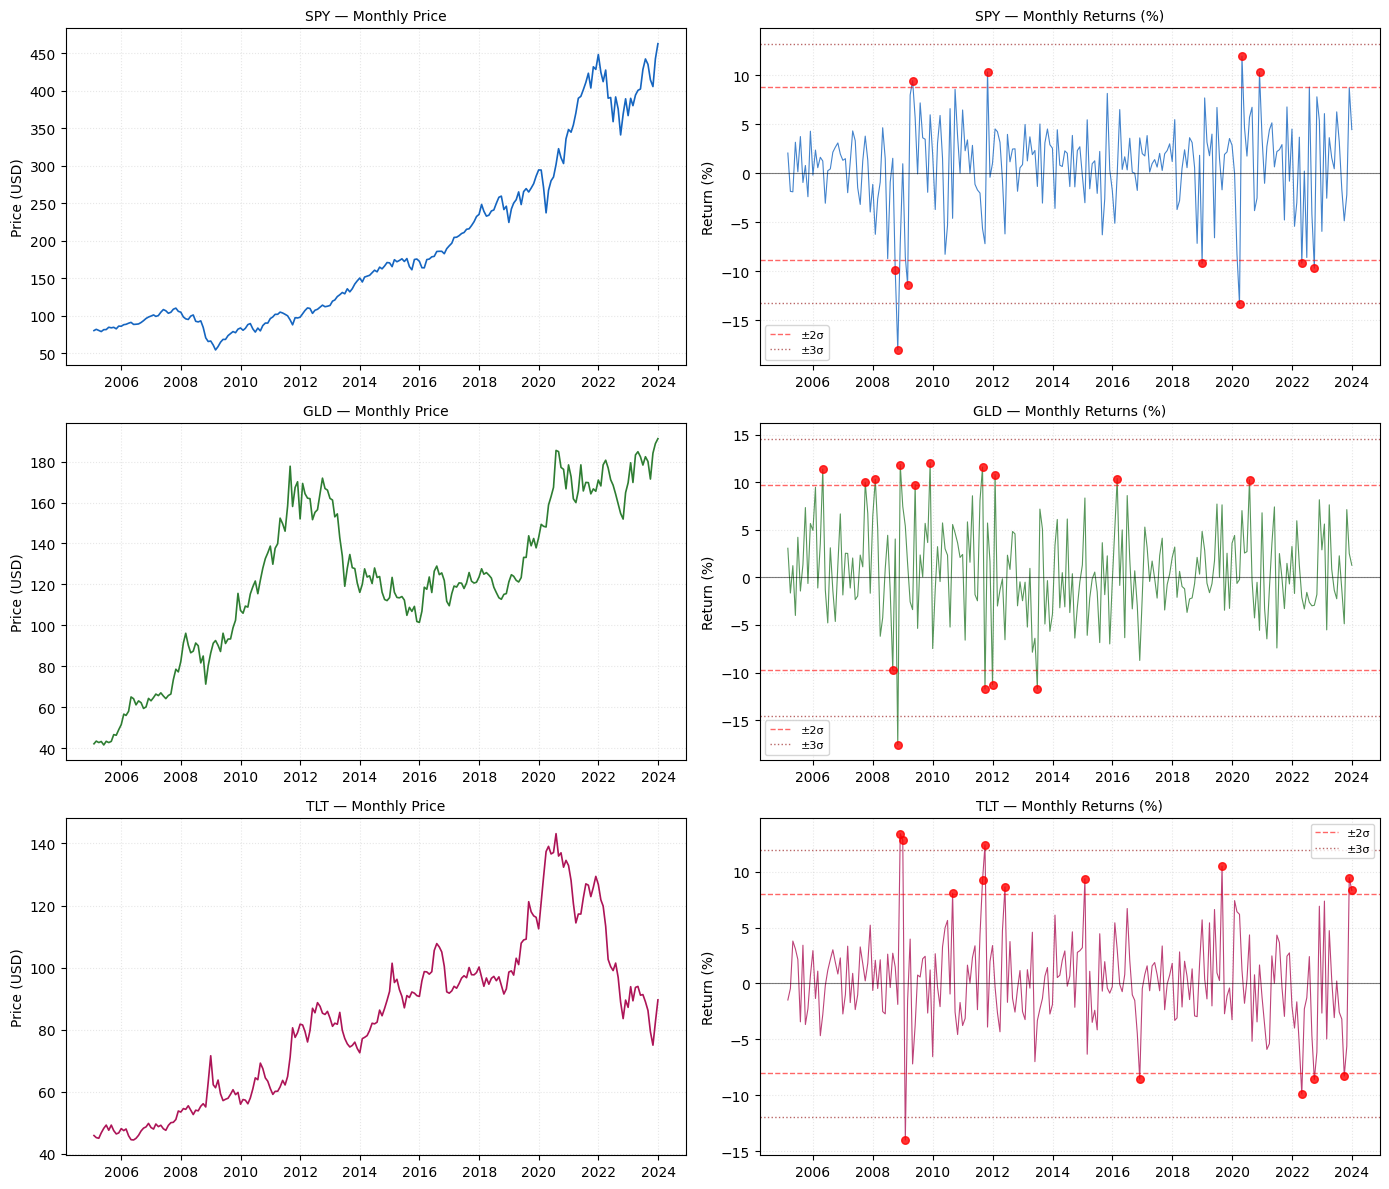

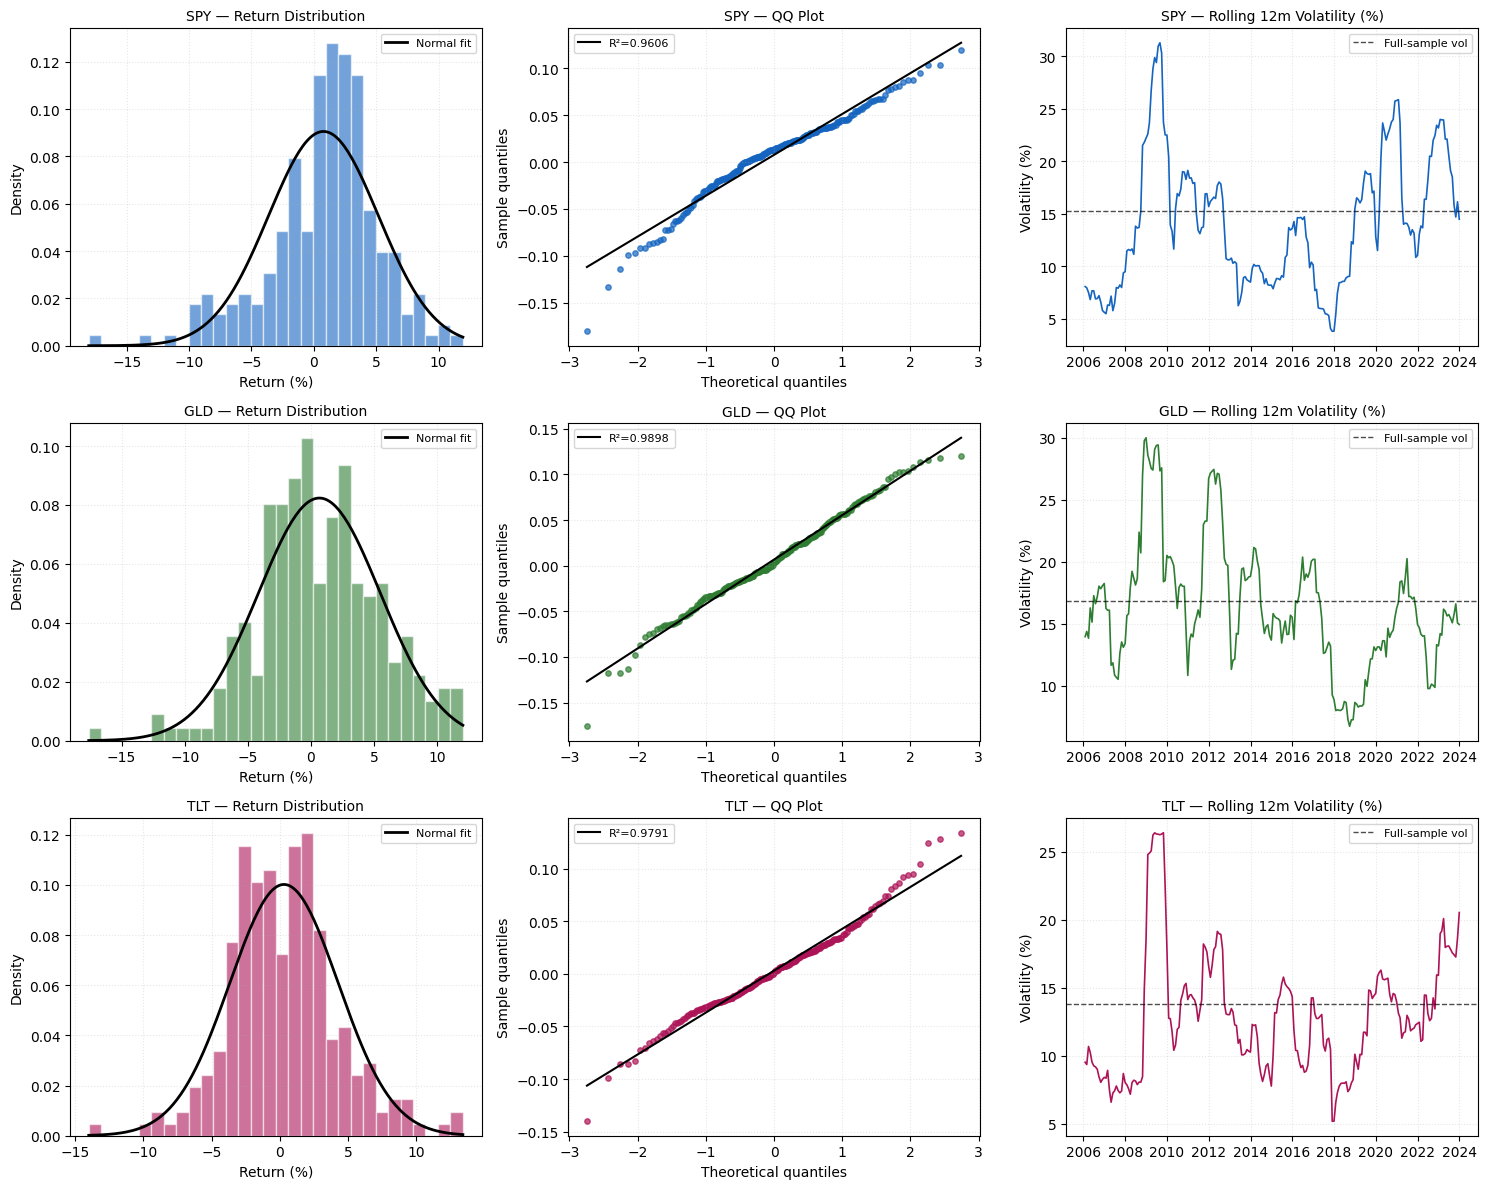

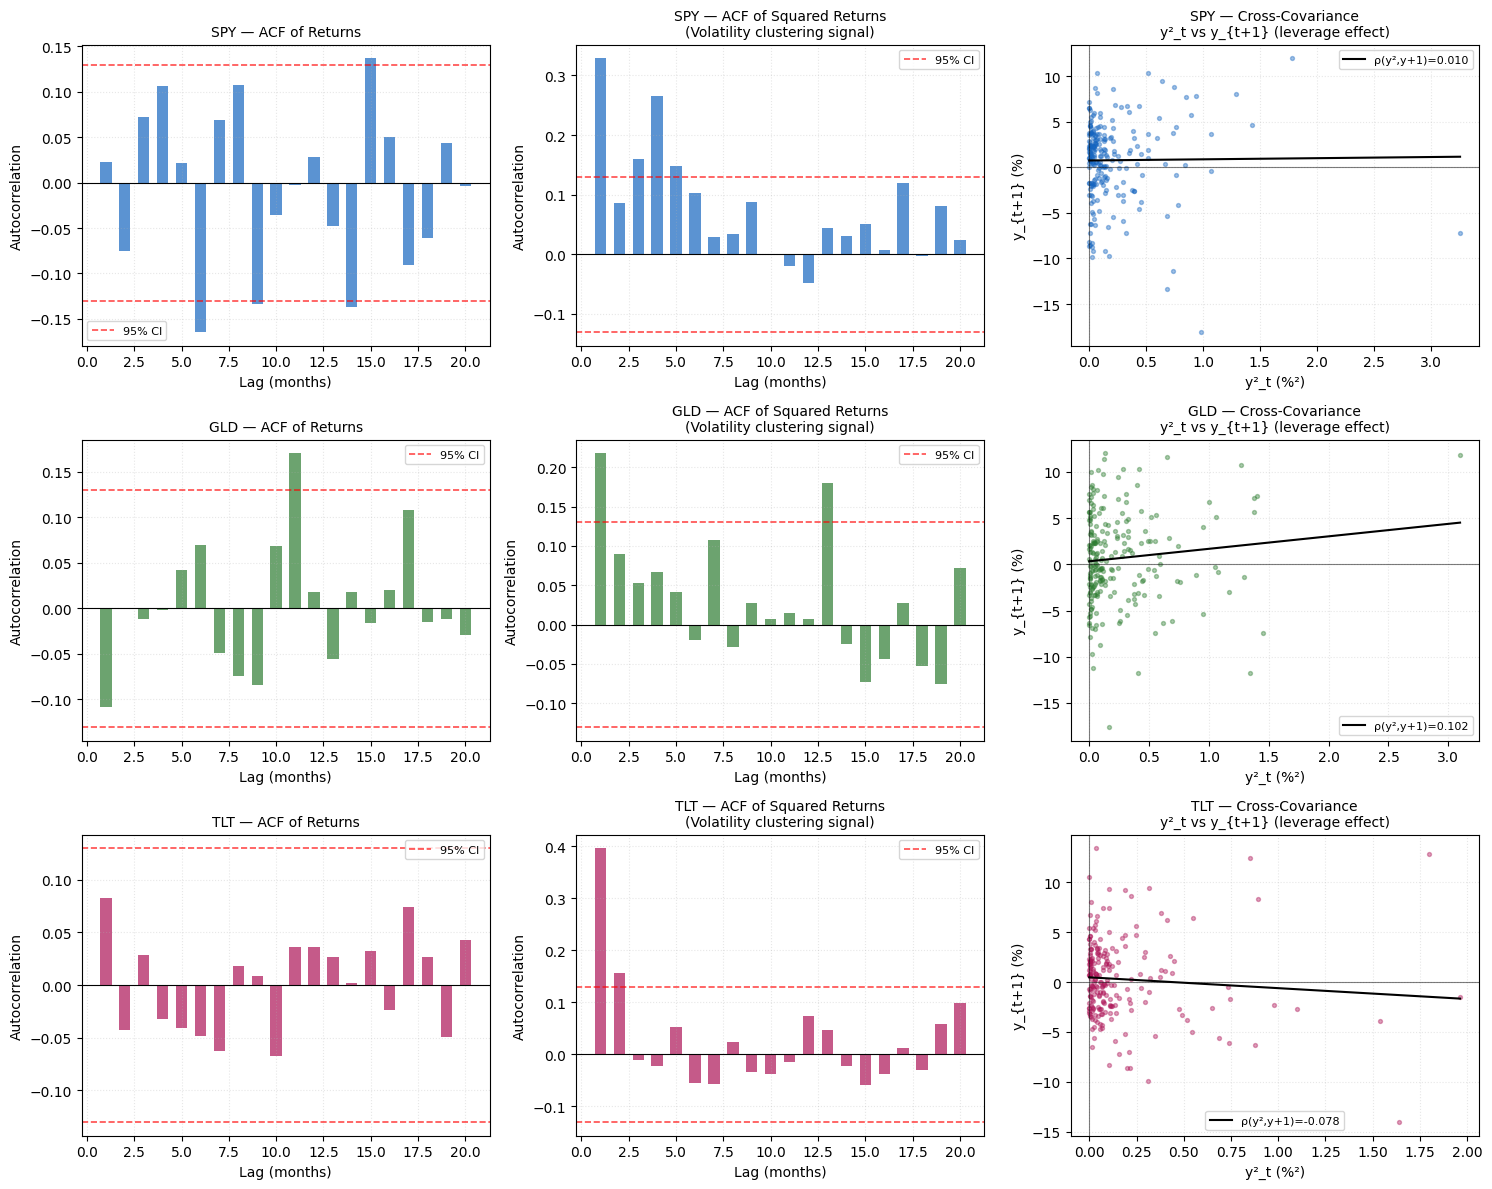

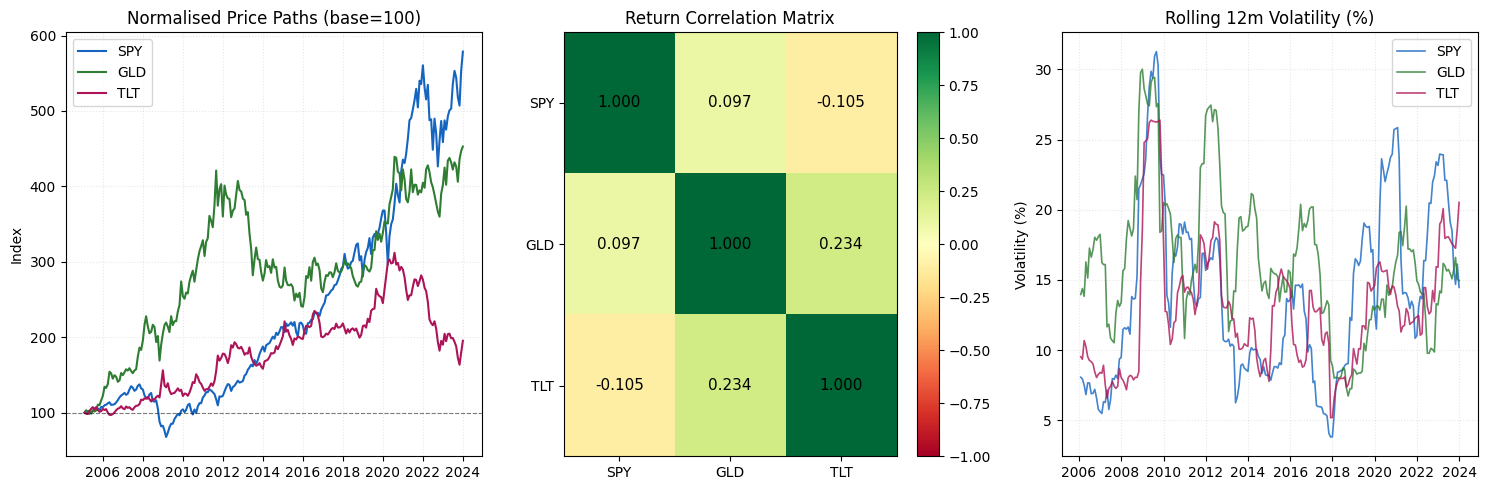

In [9]:
def eda_plots(tickers, start, end, freq='monthly'):
    """
    Full EDA pipeline for multiple assets.
    Covers: price paths, returns, distributional properties,
    autocorrelation, volatility clustering, outliers.
    """
    
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy import stats
    from scipy.stats import jarque_bera, shapiro, kurtosis, skew
    import statsmodels.api as sm
    import warnings
    warnings.filterwarnings('ignore')
    
    # ── Load data ──────────────────────────────────────────────────────────
    data = {}
    for ticker in tickers:
        raw = yf.download(ticker, start=start, end=end,
                          auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.droplevel(1)
        prices = raw['Close'].dropna()
        monthly = prices.resample('ME').last().dropna()
        ret     = pd.Series(
            np.diff(np.log(monthly.values)),
            index=monthly.index[1:]
        )
        data[ticker] = {'prices': monthly, 'ret': ret}
        print(f"  {ticker}: {len(monthly)} monthly prices, "
              f"{len(ret)} returns")

    

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 1 — Price paths and returns
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    #fig.suptitle('Figure 1 — Price Paths and Monthly Log Returns',
    #             fontsize=13, fontweight='bold')

    colors = {'SPY': '#1565C0', 'GLD': '#2E7D32', 'TLT': '#AD1457'}

    for row, (ticker, d) in enumerate(data.items()):
        prices = d['prices']
        ret    = d['ret']
        col    = colors[ticker]

        # Price path
        ax = axes[row, 0]
        ax.plot(prices.index, prices.values, lw=1.2, color=col)
        ax.set_title(f'{ticker} — Monthly Price', fontsize=10)
        ax.set_ylabel('Price (USD)')
        ax.grid(True, alpha=0.3, ls=':')

        # Returns with ±2σ bands
        ax  = axes[row, 1]
        sig = ret.std()
        ax.plot(ret.index, ret.values*100, lw=0.8,
                color=col, alpha=0.8)
        ax.axhline(0,      color='black', lw=0.8, ls='-', alpha=0.5)
        ax.axhline( 2*sig*100, color='red', lw=1.0, ls='--',
                   alpha=0.6, label='±2σ')
        ax.axhline(-2*sig*100, color='red', lw=1.0, ls='--', alpha=0.6)
        ax.axhline( 3*sig*100, color='darkred', lw=1.0, ls=':',
                   alpha=0.6, label='±3σ')
        ax.axhline(-3*sig*100, color='darkred', lw=1.0, ls=':',
                   alpha=0.6)

        # Mark outliers
        outliers = ret[np.abs(ret) > 2*sig]
        ax.scatter(outliers.index, outliers.values*100,
                   color='red', s=30, zorder=5, alpha=0.8)
        ax.set_title(f'{ticker} — Monthly Returns (%)', fontsize=10)
        ax.set_ylabel('Return (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig1_prices.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 2 — Distributional analysis
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    #fig.suptitle('Figure 2 — Distributional Analysis',
    #             fontsize=13, fontweight='bold')

    for row, (ticker, d) in enumerate(data.items()):
        ret = d['ret'].values
        col = colors[ticker]

        # Histogram with normal overlay
        ax = axes[row, 0]
        ax.hist(ret*100, bins=30, density=True,
                color=col, alpha=0.6, edgecolor='white')
        x   = np.linspace(ret.min()*100, ret.max()*100, 200)
        pdf = stats.norm.pdf(x, ret.mean()*100, ret.std()*100)
        ax.plot(x, pdf, 'k-', lw=2, label='Normal fit')
        ax.set_title(f'{ticker} — Return Distribution', fontsize=10)
        ax.set_xlabel('Return (%)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # QQ plot
        ax = axes[row, 1]
        (osm, osr), (slope, intercept, r) = stats.probplot(
            ret, dist='norm')
        ax.scatter(osm, osr, color=col, s=15, alpha=0.7)
        ax.plot(osm, slope*np.array(osm)+intercept,
                'k-', lw=1.5, label=f'R²={r**2:.4f}')
        ax.set_title(f'{ticker} — QQ Plot', fontsize=10)
        ax.set_xlabel('Theoretical quantiles')
        ax.set_ylabel('Sample quantiles')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # Rolling volatility
        ax  = axes[row, 2]
        ret_s  = d['ret']
        roll_v = ret_s.rolling(12).std() * np.sqrt(12) * 100
        ax.plot(ret_s.index, roll_v, lw=1.2, color=col)
        ax.axhline(ret_s.std()*np.sqrt(12)*100,
                   color='black', lw=1.0, ls='--',
                   alpha=0.7, label='Full-sample vol')
        ax.set_title(f'{ticker} — Rolling 12m Volatility (%)',
                     fontsize=10)
        ax.set_ylabel('Volatility (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig2_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 3 — Autocorrelation and volatility clustering
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    #fig.suptitle('Figure 3 — Autocorrelation and Volatility Clustering',
    #             fontsize=13, fontweight='bold')
    max_lag = 20

    for row, (ticker, d) in enumerate(data.items()):
        ret = d['ret'].values
        col = colors[ticker]
        N   = len(ret)
        ci  = 1.96 / np.sqrt(N)   # 95% confidence band

        # ACF of returns
        ax   = axes[row, 0]
        acf  = [np.corrcoef(ret[:-l], ret[l:])[0,1]
                for l in range(1, max_lag+1)]
        lags = range(1, max_lag+1)
        ax.bar(lags, acf, color=col, alpha=0.7, width=0.6)
        ax.axhline( ci, color='red', lw=1.2, ls='--', alpha=0.7,
                   label='95% CI')
        ax.axhline(-ci, color='red', lw=1.2, ls='--', alpha=0.7)
        ax.axhline(0,   color='black', lw=0.8)
        ax.set_title(f'{ticker} — ACF of Returns', fontsize=10)
        ax.set_xlabel('Lag (months)')
        ax.set_ylabel('Autocorrelation')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # ACF of squared returns (volatility clustering)
        ax    = axes[row, 1]
        ret2  = ret**2
        acf2  = [np.corrcoef(ret2[:-l], ret2[l:])[0,1]
                 for l in range(1, max_lag+1)]
        ax.bar(lags, acf2, color=col, alpha=0.7, width=0.6)
        ax.axhline( ci, color='red', lw=1.2, ls='--', alpha=0.7,
                   label='95% CI')
        ax.axhline(-ci, color='red', lw=1.2, ls='--', alpha=0.7)
        ax.axhline(0,   color='black', lw=0.8)
        ax.set_title(f'{ticker} — ACF of Squared Returns\n'
                     f'(Volatility clustering signal)', fontsize=10)
        ax.set_xlabel('Lag (months)')
        ax.set_ylabel('Autocorrelation')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

        # Scatter: y²_t vs y_{t+1} (cross-covariance)
        ax  = axes[row, 2]
        y2  = ret[:-1]**2
        yf  = ret[1:]
        rho_cross = np.corrcoef(y2, yf)[0, 1]
        ax.scatter(y2*100, yf*100, color=col, s=8, alpha=0.4)
        ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.5)
        ax.axvline(0, color='black', lw=0.8, ls='-', alpha=0.5)
        # Regression line
        b = np.polyfit(y2, yf, 1)
        xr = np.linspace(y2.min(), y2.max(), 100)
        ax.plot(xr*100, np.polyval(b, xr)*100, 'k-', lw=1.5,
                label=f'ρ(y²,y+1)={rho_cross:.3f}')
        ax.set_title(f'{ticker} — Cross-Covariance\n'
                     f'y²_t vs y_{{t+1}} (leverage effect)',
                     fontsize=10)
        ax.set_xlabel('y²_t (%²)')
        ax.set_ylabel('y_{t+1} (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig3_autocorr.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURE 4 — Cross-asset comparison
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    #fig.suptitle('Figure 4 — Cross-Asset Comparison',
    #             fontsize=13, fontweight='bold')

    # Normalised price paths
    ax = axes[0]
    for ticker, d in data.items():
        prices_norm = d['prices'] / d['prices'].iloc[0] * 100
        ax.plot(prices_norm.index, prices_norm.values,
                lw=1.5, color=colors[ticker], label=ticker)
    ax.axhline(100, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('Normalised Price Paths (base=100)')
    ax.set_ylabel('Index')
    ax.legend()
    ax.grid(True, alpha=0.3, ls=':')

    # Return correlation matrix
    ax = axes[1]
    ret_df = pd.DataFrame(
        {ticker: d['ret'] for ticker, d in data.items()}
    ).dropna()
    corr = ret_df.corr()
    im   = ax.imshow(corr.values, cmap='RdYlGn',
                     vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(tickers)))
    ax.set_yticks(range(len(tickers)))
    ax.set_xticklabels(tickers)
    ax.set_yticklabels(tickers)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            ax.text(j, i, f'{corr.values[i,j]:.3f}',
                    ha='center', va='center', fontsize=11,
                    color='black')
    plt.colorbar(im, ax=ax)
    ax.set_title('Return Correlation Matrix')

    # Volatility comparison — rolling 12m
    ax = axes[2]
    for ticker, d in data.items():
        roll_v = d['ret'].rolling(12).std() * np.sqrt(12) * 100
        ax.plot(roll_v.index, roll_v.values,
                lw=1.2, color=colors[ticker],
                label=ticker, alpha=0.8)
    ax.set_title('Rolling 12m Volatility (%)')
    ax.set_ylabel('Volatility (%)')
    ax.legend()
    ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('eda_fig4_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return data


# ── Run ────────────────────────────────────────────────────────────────────────
data = eda_plots(
    tickers = ['SPY', 'GLD', 'TLT'],
    start   = '2005-01-01',
    end     = '2024-01-01',
    freq    = 'monthly'
)

In [38]:
def diagnose_real_data(ret, h, ticker):
    """
    Prints diagnostics before estimation to understand
    why the estimator might struggle on real data.
    """
    samp = estimate_moments(ret)
    mean_e, var_e, lag1_e, lag2_e, cross_e = samp
    N = len(ret)

    print(f"\nDiagnostics for {ticker}:")
    print(f"  N observations   : {N}")
    print(f"  h                : {h:.5f}")
    print(f"  Mean return      : {mean_e:+.6e}")
    print(f"  Variance         : {var_e:+.6e}")
    print(f"  Lag-1 autocov    : {lag1_e:+.6e}")
    print(f"  Lag-2 autocov    : {lag2_e:+.6e}")
    print(f"  Cross-cov        : {cross_e:+.6e}")

    # Lag ratio
    if lag1_e != 0 and np.sign(lag1_e) == np.sign(lag2_e):
        ratio = lag2_e / lag1_e
        if 0 < ratio < 1:
            kappa_est = -np.log(ratio) / h
            print(f"  Lag ratio        : {ratio:.4f}  → κ ≈ {kappa_est:.4f}")
        else:
            print(f"  Lag ratio        : {ratio:.4f}  ✗ not in (0,1)")
    else:
        print(f"  Lag ratio        : invalid (sign mismatch or zero)")

    # Noise floor
    noise = var_e / np.sqrt(N)
    snr   = abs(lag1_e) / noise if noise > 0 else 0
    print(f"  Noise floor      : {noise:.4e}")
    print(f"  SNR (lag1/noise) : {snr:.2f}  "
          f"({'adequate' if snr > 2 else 'too low — estimates unreliable'})")

    # Check cross-cov sign — determines sigma_sq sign
    print(f"  Cross-cov sign   : {'positive' if cross_e > 0 else 'negative'}")
    print(f"  Lag1 sign        : {'positive' if lag1_e > 0 else 'negative'}")


# Run diagnostics first
ret_spy, h_m = load_real_data('SPY', '2005-01-01', '2024-01-01', 'monthly')
diagnose_real_data(ret_spy, h_m, 'SPY')

SPY (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 9.28%
  Ann. vol   : 15.27%

Diagnostics for SPY:
  N observations   : 227
  h                : 0.08333
  Mean return      : +7.733890e-03
  Variance         : +1.950577e-03
  Lag-1 autocov    : +4.518254e-05
  Lag-2 autocov    : -1.467628e-04
  Cross-cov        : +1.482645e-06
  Lag ratio        : invalid (sign mismatch or zero)
  Noise floor      : 1.2946e-04
  SNR (lag1/noise) : 0.35  (too low — estimates unreliable)
  Cross-cov sign   : positive
  Lag1 sign        : positive


In [ ]:
# Expected SNR for SPY with N=227, h=21/252

import numpy as np
h = 21/252
ht = (1-np.exp(-2*h))/2
lag1_theory = (ht**2*0.04*0.3/2)*(0.3/(4*2)+0.7)
noise = 0.04*h/np.sqrt(227)
print(f"Theoretical lag1 : {lag1_theory:.4e}")
print(f"Noise floor      : {noise:.4e}")
print(f"SNR              : {lag1_theory/noise:.2f}")


Theoretical lag1 : 2.6072e-05
Noise floor      : 2.2124e-04
SNR              : 0.12


In [61]:
# Run diagnostics first
ret_spy, h_m = load_real_data('SPY', '2005-01-01', '2024-01-01', 'monthly')
diagnose_real_data(ret_spy, h_m, 'SPY')

SPY (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 9.28%
  Ann. vol   : 15.27%

Diagnostics for SPY:
  N observations   : 227
  h                : 0.08333
  Mean return      : +7.733890e-03
  Variance         : +1.950577e-03
  Lag-1 autocov    : +4.518254e-05
  Lag-2 autocov    : -1.467628e-04
  Cross-cov        : +1.482645e-06
  Lag ratio        : invalid (sign mismatch or zero)
  Noise floor      : 1.2946e-04
  SNR (lag1/noise) : 0.35  (too low — estimates unreliable)
  Cross-cov sign   : positive
  Lag1 sign        : positive


In [59]:
# Run diagnostics first
ret_gld, h_m = load_real_data('GLD', '2005-01-01', '2024-01-01', 'monthly')
diagnose_real_data(ret_gld, h_m, 'GLD')

GLD (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 7.98%
  Ann. vol   : 16.78%

Diagnostics for GLD:
  N observations   : 227
  h                : 0.08333
  Mean return      : +6.653167e-03
  Variance         : +2.357512e-03
  Lag-1 autocov    : -2.548074e-04
  Lag-2 autocov    : +1.764479e-06
  Cross-cov        : +1.819774e-05
  Lag ratio        : invalid (sign mismatch or zero)
  Noise floor      : 1.5647e-04
  SNR (lag1/noise) : 1.63  (too low — estimates unreliable)
  Cross-cov sign   : positive
  Lag1 sign        : negative


In [60]:
# Run diagnostics first
ret_tlt, h_m = load_real_data('TLT', '2005-01-01', '2024-01-01', 'monthly')
diagnose_real_data(ret_tlt, h_m, 'TLT')

TLT (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 3.54%
  Ann. vol   : 13.79%

Diagnostics for TLT:
  N observations   : 227
  h                : 0.08333
  Mean return      : +2.948090e-03
  Variance         : +1.592078e-03
  Lag-1 autocov    : +1.311545e-04
  Lag-2 autocov    : -6.714945e-05
  Cross-cov        : -8.914171e-06
  Lag ratio        : invalid (sign mismatch or zero)
  Noise floor      : 1.0567e-04
  SNR (lag1/noise) : 1.24  (too low — estimates unreliable)
  Cross-cov sign   : negative
  Lag1 sign        : positive


In [46]:
# For SPY: test only mean and variance (well-identified moments)
ret_spy, h_m = load_real_data('SPY', '2005-01-01', '2024-01-01', 'monthly')

print("Testing only mean and variance (well-identified moments):")
goodness_of_fit_test_robust(ret_spy, h_m, n_boot=200,
                             moments_to_test=[0, 1])

print("\nTesting all five moments with Bonferroni correction:")
goodness_of_fit_test_robust(ret_spy, h_m, n_boot=200,
                             moments_to_test=[0, 1, 2, 3, 4])

SPY (monthly): 228 prices → 227 returns
  NaN in ret: 0
  Ann. return: 9.28%
  Ann. vol   : 15.27%
Testing only mean and variance (well-identified moments):

GoF Test  (Bonferroni α = 0.0250 per moment, testing 2 moments)
Moment                   Empirical     Boot Mean    Boot Std     p-value   Adequate?
--------------------------------------------------------------------------------
  Mean                  7.7339e-03    2.1127e-03  1.2294e-02       0.050           ✓
  Variance              1.9506e-03    1.3272e-02  3.9398e-02       0.750           ✓

  Joint conclusion: H0 not rejected — Heston adequate

Testing all five moments with Bonferroni correction:

GoF Test  (Bonferroni α = 0.0100 per moment, testing 5 moments)
Moment                   Empirical     Boot Mean    Boot Std     p-value   Adequate?
--------------------------------------------------------------------------------
  Mean                  7.7339e-03    3.6901e-03  5.1930e-03       0.050           ✓
  Variance       

array([[ 1.24722550e-03,  1.77807352e-02,  3.97535858e-03,
         2.69914901e-03, -1.11456217e-03],
       [ 5.67172814e-03,  1.00201636e-03, -2.75190572e-05,
        -5.94535291e-05, -6.55933043e-05],
       [ 4.80670164e-03,  2.17900479e-03,  1.32980259e-04,
         3.25390210e-04, -2.35384501e-05],
       [ 5.57166107e-03,  4.06732671e-04, -1.18776097e-04,
        -7.02414262e-05, -6.53988911e-06],
       [ 3.00414380e-03,  9.93533109e-03, -1.08244475e-03,
        -2.21475043e-03, -1.26850682e-03],
       [ 3.43879361e-03,  6.16908895e-03, -6.56162251e-04,
        -3.31048042e-04, -1.56073652e-04],
       [ 5.28575263e-03,  6.46851307e-04, -4.84056055e-05,
        -9.60159828e-05, -3.70283538e-05],
       [ 4.83543318e-03,  1.09930251e-03,  1.62800122e-04,
        -1.84391910e-04,  4.08881660e-07],
       [-9.40056832e-04,  2.50281610e-02, -1.93296981e-04,
         1.39550506e-03, -5.20535527e-04],
       [ 5.25516197e-03,  1.50777827e-03, -2.81837532e-04,
        -1.71153554e-04

In [49]:
def newey_west(z, lag_max):
    
    N, k = z.shape
    Sigma = (z.T @ z) / N # lag-0 term
    
    for lag in range(1, lag_max + 1):
        w = 1 - lag / (lag_max + 1)
        Gamma = (z[lag:].T @ z[:-lag]) / N
        Sigma += w * (Gamma + Gamma.T)
        
    return Sigma

def moment_conditions(ret, params):
    mu, theta, kappa, sigma_V, rho = params
    N = len(ret)
    Ybar = np.mean(ret)
    Y2bar = np.mean(ret ** 2)
    
    # Moments per obs
    z = np.zeros((N, 5))
    z[:, 0] = ret - Ybar                                    # mean
    z[:, 1] = (ret - Ybar) ** 2 - np.var(ret, ddof = 1)     # var
    cov1 = lagm_cov_est(ret, 1)
    z[:-1, 2] = (ret[:-1] - Ybar) * (ret[1:] - Ybar) - cov1     # lag1

    cov2 = lagm_cov_est(ret, 2)
    z[:-2, 3] = (ret[:-2] - Ybar) * (ret[2:] - Ybar) - cov2     # lag2

    y2    = ret[:-1]**2
    y2bar = np.mean(y2)
    cross = np.mean((y2 - y2bar) * (ret[1:] - np.mean(ret[1:])))
    z[:-1, 4] = (y2 - y2bar) * (ret[1:] - Ybar) - cross         # cross
    return z

In [65]:
TRUE_paper = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
h_paper    = 1.0

In [56]:
# Quick size diagnostic
ret_test = heston_returns(
    float(TRUE_paper['theta']), int(400_000),
    float(TRUE_paper['mu']), float(TRUE_paper['theta']),
    float(TRUE_paper['kappa']), float(TRUE_paper['sigma_V']),
    float(TRUE_paper['rho']), float(h_paper), int(20)
)
est_test = estimate_heston_from_returns(ret_test, h_paper, verbose=False)
var_y    = np.var(ret_test, ddof=1)
lag1     = lagm_cov_est(ret_test, 1)
N        = len(ret_test)

print(f"var_y = {var_y:.6f}  (true theta = {TRUE_paper['theta']})")
print(f"lag1  = {lag1:.6e}")
print(f"kappa = {est_test['kappa']:.6f}  (true = {TRUE_paper['kappa']})")
print()
for m in [3, 4, 5]:
    lagm_emp  = lagm_cov_est(ret_test, m)
    ek        = np.exp(-(m-1)*est_test['kappa']*h_paper)
    lagm_pred = ek * lag1
    se_m      = (var_y / np.sqrt(N)) * np.sqrt(1 + ek**2)
    z         = (lagm_emp - lagm_pred) / se_m
    print(f"  lag-{m}: emp={lagm_emp:.4e}  pred={lagm_pred:.4e}  "
          f"se={se_m:.4e}  Z={z:.3f}")

var_y = 0.261257  (true theta = 0.25)
lag1  = 1.171679e-02
kappa = 0.109659  (true = 0.1)

  lag-3: emp=9.0069e-03  pred=9.4094e-03  se=5.2980e-04  Z=-0.760
  lag-4: emp=8.3871e-03  pred=8.4321e-03  se=5.0893e-04  Z=-0.088
  lag-5: emp=7.5587e-03  pred=7.5564e-03  se=4.9154e-04  Z=0.005


In [ ]:
def lag_autocov_test(ret, h, test_lags=[3, 4, 5], alpha=0.05):
    """
    Tests whether higher-order autocovariances are zero.
    
    H0: Cov(y_n, y_{n+m}) = 0  for m in test_lags  (consistent with BS)
    H1: Cov(y_n, y_{n+m}) != 0                       (consistent with Heston)
    
    No parameter estimation needed — correct size by construction.
    Under H0: Z_m = lag_m / (var_y/sqrt(N)) ~ N(0,1)
    """
    from scipy.stats import norm

    N     = len(ret)
    var_y = np.var(ret, ddof=1)
    se    = var_y / np.sqrt(N)   # Bartlett SE for zero-autocorrelation null

    print(f"\nAutocovariance Test  (N={N:,})")
    print(f"H0: Cov(y_n, y_{{n+m}}) = 0  for m = {test_lags}")
    print(f"\n{'Lag':>5s}  {'lag_m':>14s}  {'SE':>12s}  "
          f"{'Z-stat':>8s}  {'p-value':>10s}  {'OK?':>5s}")
    print("-" * 62)

    p_vals = []
    for m in test_lags:
        lagm  = lagm_cov_est(ret, m)
        z_m   = lagm / se
        p_val = 2*(1 - norm.cdf(abs(z_m)))
        p_vals.append(p_val)
        ok    = '✓' if p_val >= alpha/len(test_lags) else '✗'
        print(f"  {m:>3d}  {lagm:>14.6e}  {se:>12.4e}  "
              f"{z_m:>8.3f}  {p_val:>10.4f}  {ok:>5s}")

    valid_p = [p for p in p_vals if np.isfinite(p)]
    bon_p   = min(min(valid_p)*len(valid_p), 1.0) if valid_p else np.nan
    verdict = '✓ Cannot reject H0' if bon_p >= alpha else '✗ Reject H0'
    print(f"\n  Bonferroni p-value: {bon_p:.4f}  {verdict}")
    return p_vals


def power_analysis_lag_test(TRUE_heston, h, n_sim=500, N_vals=None):
    """
    Power analysis for the autocovariance test.
    Correct size because no parameters are estimated.
    """
    from scipy.stats import norm

    if N_vals is None:
        N_vals = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000]

    n_sub     = int(20)
    alpha     = 0.05
    test_lags = [3, 4, 5]

    def run_test(ret):
        var_y  = np.var(ret, ddof=1)
        se     = var_y / np.sqrt(len(ret))
        p_list = []
        for m in test_lags:
            lagm  = lagm_cov_est(ret, m)
            z_m   = lagm / se
            p_val = 2*(1 - norm.cdf(abs(z_m)))
            p_list.append(p_val)
        bon_p = min(min(p_list)*len(p_list), 1.0)
        return bon_p

    # ── Step 1: Size under H0 = BS ─────────────────────────────────────────
    print("Step 1 — Test size under H0 = Black-Scholes …")
    size_rej = 0
    size_n   = 500
    sigma    = np.sqrt(TRUE_heston['theta'])
    mu       = TRUE_heston['mu']

    for s in range(size_n):
        ret_bs = np.random.normal(
            (mu - 0.5*sigma**2)*h, sigma*np.sqrt(h), 1000
        )
        bon_p = run_test(ret_bs)
        if bon_p < alpha:
            size_rej += 1

    print(f"  Test size (BS, N=1000): {size_rej/size_n*100:.1f}%  (target ~5%)\n")

    # ── Step 2: Size under H0 = Heston ────────────────────────────────────
    print("Step 2 — Rejection rate under Heston (should be HIGH) …")
    heston_rej = 0
    heston_n   = 200

    for s in range(heston_n):
        ret_h = heston_returns(
            float(TRUE_heston['theta']), int(10_000),
            float(TRUE_heston['mu']), float(TRUE_heston['theta']),
            float(TRUE_heston['kappa']), float(TRUE_heston['sigma_V']),
            float(TRUE_heston['rho']), float(h), n_sub
        )
        bon_p = run_test(ret_h)
        if bon_p < alpha:
            heston_rej += 1

    print(f"  Rejection rate (Heston, N=10k): "
          f"{heston_rej/heston_n*100:.1f}%  (higher = more power)\n")

    # ── Step 3: Power curve — BS data, test whether lags nonzero ──────────
    print("Step 3 — Power curve (H0: BS, H1: Heston)")
    print(f"{'N':>8s}  {'Power':>8s}  {'Yrs monthly':>14s}  "
          f"{'Yrs weekly':>12s}  {'Valid':>7s}")
    print("-" * 56)

    results = []
    for N in N_vals:
        rejections = 0
        valid      = 0

        for s in range(n_sim):
            # Simulate from HESTON — test whether lags are detectable
            ret_h = heston_returns(
                float(TRUE_heston['theta']), int(N),
                float(TRUE_heston['mu']), float(TRUE_heston['theta']),
                float(TRUE_heston['kappa']), float(TRUE_heston['sigma_V']),
                float(TRUE_heston['rho']), float(h), n_sub
            )
            bon_p = run_test(ret_h)
            if np.isfinite(bon_p):
                if bon_p < alpha:
                    rejections += 1
                valid += 1

        power = rejections/valid if valid > 0 else np.nan
        results.append({'N': N, 'power': power})
        print(f"  {N:>6,}  {power:>7.1%}  {N/12:>12.1f} yrs  "
              f"{N/52:>10.1f} yrs  {valid:>7d}")

    # ── Step 4: Minimum N for 80% power ───────────────────────────────────
    powers = [r['power'] for r in results]
    n_80   = None
    for i in range(len(powers)-1):
        if (np.isfinite(powers[i]) and np.isfinite(powers[i+1]) and
                powers[i] < 0.8 <= powers[i+1]):
            frac = (0.8-powers[i])/(powers[i+1]-powers[i])
            n_80 = int(N_vals[i] + frac*(N_vals[i+1]-N_vals[i]))
            break

    print(f"\nMinimum N to detect Heston autocorrelation at 80% power:")
    if n_80:
        print(f"  N ≈ {n_80:,} observations")
        print(f"  Monthly (h=21/252) : ~{n_80//12:,} years")
        print(f"  Weekly  (h=5/252)  : ~{n_80//52:,} years")
        print(f"  SPY (N=227 monthly): estimated power ≈ "
              f"{float(np.interp(227, N_vals, powers)):.1%}")
    else:
        max_p = max(p for p in powers if np.isfinite(p))
        print(f"  80% power not reached. Max: {max_p:.1%}")

    return results, n_80


# ── Run ────────────────────────────────────────────────────────────────────────
TRUE_paper = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
h_paper    = 1.0

results, n_80 = power_analysis_lag_test(
    TRUE_heston = TRUE_paper,
    h           = h_paper,
    n_sim       = 500,
    N_vals      = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000]
)

# ── Apply to real data ─────────────────────────────────────────────────────────
print("\n" + "="*55)
print("Real data — testing for stochastic volatility signal")
print("="*55)

for ticker, ret in [('SPY', ret_spy), ('GLD', ret_gld), ('TLT', ret_tlt)]:
    print(f"\n{ticker} (N={len(ret):,} monthly returns):")
    lag_autocov_test(ret, h=21/252, test_lags=[3, 4, 5])

Step 1 — Test size under H0 = Black-Scholes …
  Test size (BS, N=1000): 7.8%  (target ~5%)

Step 2 — Rejection rate under Heston (should be HIGH) …
  Rejection rate (Heston, N=10k): 97.5%  (higher = more power)

Step 3 — Power curve (H0: BS, H1: Heston)
       N     Power     Yrs monthly    Yrs weekly    Valid
--------------------------------------------------------
      50     4.4%           4.2 yrs         1.0 yrs      500
     100     5.8%           8.3 yrs         1.9 yrs      500
     200    10.2%          16.7 yrs         3.8 yrs      500
     500    14.2%          41.7 yrs         9.6 yrs      500
   1,000    25.4%          83.3 yrs        19.2 yrs      500
   2,000    37.6%         166.7 yrs        38.5 yrs      500
   5,000    76.4%         416.7 yrs        96.2 yrs      500
  10,000    95.6%         833.3 yrs       192.3 yrs      500
  50,000   100.0%        4166.7 yrs       961.5 yrs      500
  100,000   100.0%        8333.3 yrs      1923.1 yrs      500

Minimum N to detect

In [64]:
def interpret_results(ticker, p_vals, N, power_at_N):
    """
    Prints a concise interpretation of the GoF test results
    accounting for test power.
    """
    from scipy.stats import norm

    bon_p   = min(min(p for p in p_vals if np.isfinite(p))*3, 1.0)
    rejects = bon_p < 0.05

    print(f"\n{ticker} — Interpretation")
    print(f"  N = {N:,} monthly returns  (test power ≈ {power_at_N:.1%})")
    print(f"  Bonferroni p = {bon_p:.4f}  "
          f"({'reject H0' if rejects else 'cannot reject H0'})")

    if not rejects:
        print(f"\n  The test does not reject the null of zero autocovariance.")
        print(f"  However, with only {N:,} observations the test has only "
              f"~{power_at_N:.0%} power.")
        print(f"  This means even if Heston stochastic volatility were present,")
        print(f"  the test would fail to detect it ~{1-power_at_N:.0%} of the time.")
        print(f"  Conclusion: the result is UNINFORMATIVE, not evidence against")
        print(f"  stochastic volatility.")
    else:
        print(f"\n  The test rejects zero autocovariance — evidence of")
        print(f"  stochastic volatility structure in monthly returns.")


# Interpolate power at N=227 from the power curve
power_227 = float(np.interp(227,
                             [r['N'] for r in results],
                             [r['power'] for r in results]))

for ticker, p_vals_real in [
    ('SPY', lag_autocov_test(ret_spy, 21/252)),
    ('GLD', lag_autocov_test(ret_gld, 21/252)),
    ('TLT', lag_autocov_test(ret_tlt, 21/252)),
]:
    interpret_results(ticker, p_vals_real, 227, power_227)


Autocovariance Test  (N=227)
H0: Cov(y_n, y_{n+m}) = 0  for m = [3, 4, 5]

  Lag           lag_m            SE    Z-stat     p-value    OK?
--------------------------------------------------------------
    3    1.414496e-04    1.2946e-04     1.093      0.2746      ✓
    4    2.069790e-04    1.2946e-04     1.599      0.1099      ✓
    5    4.304023e-05    1.2946e-04     0.332      0.7396      ✓

  Bonferroni p-value: 0.3296  ✓ Cannot reject H0

Autocovariance Test  (N=227)
H0: Cov(y_n, y_{n+m}) = 0  for m = [3, 4, 5]

  Lag           lag_m            SE    Z-stat     p-value    OK?
--------------------------------------------------------------
    3   -2.817008e-05    1.5647e-04    -0.180      0.8571      ✓
    4   -3.308016e-06    1.5647e-04    -0.021      0.9831      ✓
    5    9.988893e-05    1.5647e-04     0.638      0.5232      ✓

  Bonferroni p-value: 1.0000  ✓ Cannot reject H0

Autocovariance Test  (N=227)
H0: Cov(y_n, y_{n+m}) = 0  for m = [3, 4, 5]

  Lag           lag_m     

Estimating parameters for each asset …
  SPY: κ=0.146  θ=0.0229  σ_V=0.972  ρ=0.999
  GLD: κ=6.620  θ=0.0326  σ_V=2.000  ρ=0.999
  TLT: κ=4.153  θ=0.0171  σ_V=2.000  ρ=-0.999

Computing power curves (this takes a few minutes) …
  SPY …
  GLD …
  TLT …
  Paper parameters …


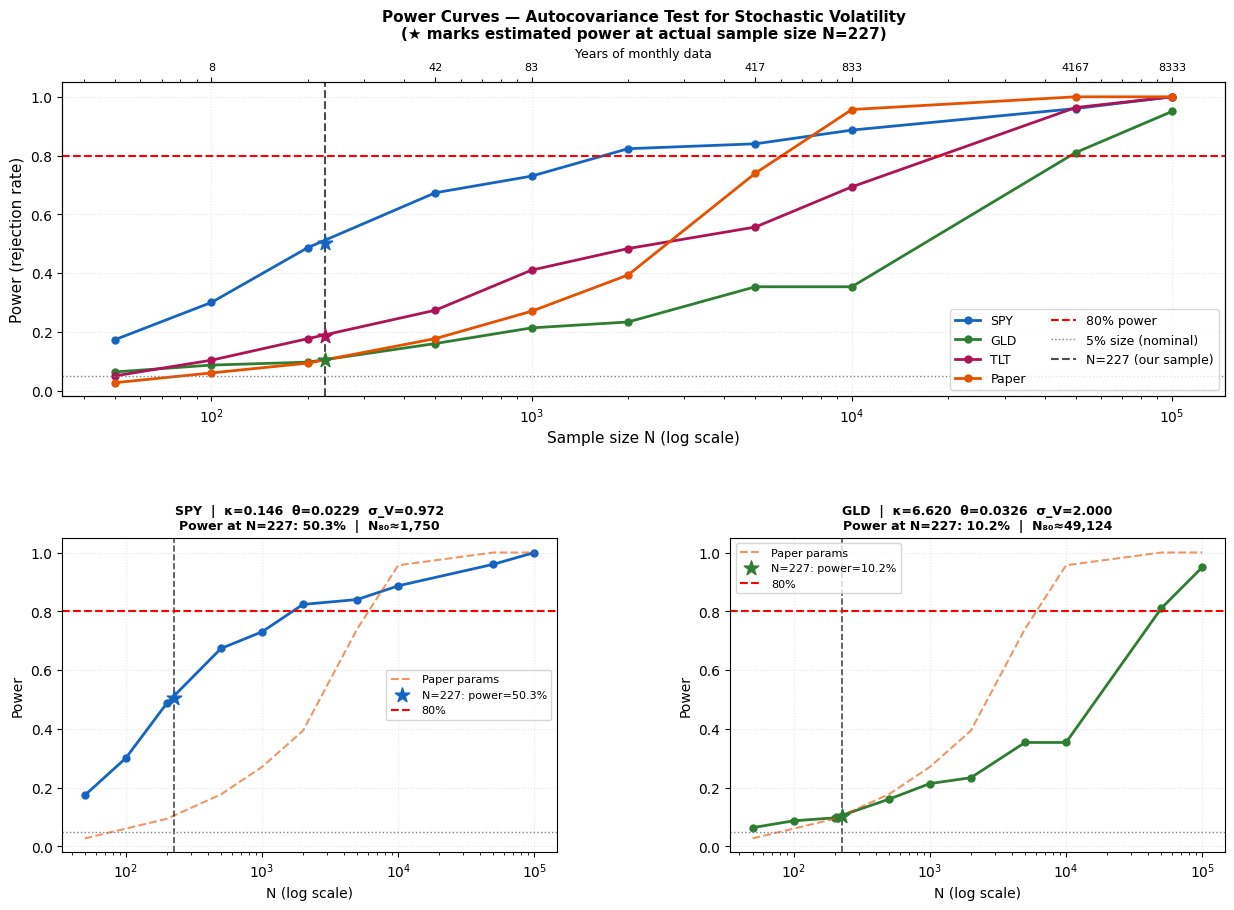

Saved to power_curves.png

Ticker         κ        θ     σ_V   Power@227     N for 80%   Yrs (monthly)
----------------------------------------------------------------------
  SPY      0.146   0.0229   0.972      50.3%         1,750           145 yrs
  GLD      6.620   0.0326   2.000      10.2%        49,124         4,093 yrs
  TLT      4.153   0.0171   2.000      18.5%        25,802         2,150 yrs


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import norm

def power_curve_per_asset(asset_params, h, n_sim=300,
                           N_vals=None, n_sub=20):
    """
    Computes the power curve for a specific set of Heston parameters.
    Used to show how power differs across assets.
    """
    if N_vals is None:
        N_vals = [50, 100, 200, 500, 1000, 2000, 5000,
                  10000, 50000, 100000]

    test_lags = [3, 4, 5]
    alpha     = 0.05

    def run_test(ret):
        var_y  = np.var(ret, ddof=1)
        se     = var_y / np.sqrt(len(ret))
        p_list = []
        for m in test_lags:
            lagm  = lagm_cov_est(ret, m)
            z_m   = lagm / se
            p_val = 2*(1 - norm.cdf(abs(z_m)))
            p_list.append(p_val)
        return min(min(p_list)*len(p_list), 1.0)

    powers = []
    for N in N_vals:
        rejections = 0
        valid      = 0
        for s in range(n_sim):
            ret_h = heston_returns(
                float(asset_params['theta']), int(N),
                float(asset_params['mu']),    float(asset_params['theta']),
                float(asset_params['kappa']), float(asset_params['sigma_V']),
                float(asset_params['rho']),   float(h), n_sub
            )
            bon_p = run_test(ret_h)
            if np.isfinite(bon_p):
                if bon_p < alpha:
                    rejections += 1
                valid += 1
        power = rejections/valid if valid > 0 else np.nan
        powers.append(power)

    return powers


def plot_power_curves(asset_results, N_vals, N_actual,
                      h_monthly=21/252, save_path='power_curves.png'):
    """
    Plots power curves for multiple assets on shared axes.

    asset_results : dict — {ticker: {'powers': [...], 'est': {...}, 'color': ...}}
    N_vals        : list of N values used
    N_actual      : actual sample size of the real datasets
    """
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

    colors = {'SPY': '#1565C0', 'GLD': '#2E7D32', 'TLT': '#AD1457',
              'Paper': '#E65100'}

    # ── Panel 1: All power curves on one plot ─────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])

    for ticker, res in asset_results.items():
        powers = res['powers']
        valid  = [np.isfinite(p) for p in powers]
        N_plot = [N for N, v in zip(N_vals, valid) if v]
        P_plot = [p for p, v in zip(powers, valid) if v]
        ax1.plot(N_plot, P_plot, 'o-',
                 color=colors.get(ticker, 'grey'),
                 lw=2, ms=5, label=ticker)

        # Mark the actual N for real assets
        if ticker != 'Paper':
            p_at_N = float(np.interp(N_actual, N_vals, powers))
            ax1.scatter(N_actual, p_at_N,
                        color=colors.get(ticker, 'grey'),
                        s=120, zorder=6, marker='*')

    ax1.axhline(0.80, color='red',   lw=1.5, ls='--', label='80% power')
    ax1.axhline(0.05, color='grey',  lw=1.0, ls=':',  label='5% size (nominal)')
    ax1.axvline(N_actual, color='black', lw=1.5, ls='--',
                label=f'N={N_actual} (our sample)', alpha=0.7)

    ax1.set_xscale('log')
    ax1.set_xlabel('Sample size N (log scale)', fontsize=11)
    ax1.set_ylabel('Power (rejection rate)', fontsize=11)
    ax1.set_title('Power Curves — Autocovariance Test for Stochastic Volatility\n'
                  '(★ marks estimated power at actual sample size N=227)',
                  fontsize=11, fontweight='bold')
    ax1.set_ylim(-0.02, 1.05)
    ax1.legend(fontsize=9, ncol=2)
    ax1.grid(True, alpha=0.3, ls=':')

    # Secondary x-axis showing years of monthly data
    ax1b = ax1.twiny()
    ax1b.set_xscale('log')
    ax1b.set_xlim(ax1.get_xlim())
    tick_N    = [100, 500, 1000, 5000, 10000, 50000, 100000]
    tick_yrs  = [N/12 for N in tick_N]
    tick_labs = [f'{N/12:.0f}' for N in tick_N]
    ax1b.set_xticks(tick_N)
    ax1b.set_xticklabels(tick_labs, fontsize=8)
    ax1b.set_xlabel('Years of monthly data', fontsize=9)

    # ── Panels 2-4: Individual asset panels ───────────────────────────────
    panel_positions = [gs[1, 0], gs[1, 1]]
    real_assets     = {k: v for k, v in asset_results.items() if k != 'Paper'}

    for idx, (ticker, res) in enumerate(real_assets.items()):
        if idx >= 2:
            break
        ax  = fig.add_subplot(panel_positions[idx])
        est = res['est']
        powers = res['powers']

        # Power curve
        valid  = [np.isfinite(p) for p in powers]
        N_plot = [N for N, v in zip(N_vals, valid) if v]
        P_plot = [p for p, v in zip(powers, valid) if v]
        ax.plot(N_plot, P_plot, 'o-',
                color=colors.get(ticker, 'grey'), lw=2, ms=5)

        # Paper parameters for comparison
        if 'Paper' in asset_results:
            p_paper = asset_results['Paper']['powers']
            v_paper = [np.isfinite(p) for p in p_paper]
            N_pp    = [N for N, v in zip(N_vals, v_paper) if v]
            P_pp    = [p for p, v in zip(p_paper, v_paper) if v]
            ax.plot(N_pp, P_pp, '--',
                    color=colors['Paper'], lw=1.5, alpha=0.6,
                    label='Paper params')

        # Mark actual N
        p_at_N = float(np.interp(N_actual, N_vals, powers))
        ax.axvline(N_actual, color='black', lw=1.2, ls='--', alpha=0.7)
        ax.scatter(N_actual, p_at_N,
                   color=colors.get(ticker, 'grey'),
                   s=120, zorder=6, marker='*',
                   label=f'N={N_actual}: power={p_at_N:.1%}')

        ax.axhline(0.80, color='red',  lw=1.5, ls='--', label='80%')
        ax.axhline(0.05, color='grey', lw=1.0, ls=':')
        ax.set_xscale('log')
        ax.set_ylim(-0.02, 1.05)
        ax.set_xlabel('N (log scale)', fontsize=10)
        ax.set_ylabel('Power', fontsize=10)

        # Minimum N for 80%
        n_80 = None
        for i in range(len(powers)-1):
            if (np.isfinite(powers[i]) and np.isfinite(powers[i+1]) and
                    powers[i] < 0.8 <= powers[i+1]):
                frac = (0.8-powers[i])/(powers[i+1]-powers[i])
                n_80 = int(N_vals[i] + frac*(N_vals[i+1]-N_vals[i]))
                break

        n80_str = f'N₈₀≈{n_80:,}' if n_80 else 'N₈₀>100k'
        title   = (f"{ticker}  |  κ={est['kappa']:.3f}  "
                   f"θ={est['theta']:.4f}  σ_V={est['sigma_V']:.3f}\n"
                   f"Power at N=227: {p_at_N:.1%}  |  {n80_str}")
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")


# ── Run ────────────────────────────────────────────────────────────────────────
N_vals   = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000]
h_m      = 21/252
N_actual = 227

# Estimate parameters for each real asset
print("Estimating parameters for each asset …")
asset_est = {}
for ticker, ret in [('SPY', ret_spy), ('GLD', ret_gld), ('TLT', ret_tlt)]:
    try:
        est = estimate_heston_from_returns(ret, h_m, verbose=False)
        asset_est[ticker] = est
        print(f"  {ticker}: κ={est['kappa']:.3f}  θ={est['theta']:.4f}  "
              f"σ_V={est['sigma_V']:.3f}  ρ={est['rho']:.3f}")
    except Exception as ex:
        print(f"  {ticker}: failed — {ex}")

# Paper parameters as baseline
TRUE_paper = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)

# Compute power curves
print("\nComputing power curves (this takes a few minutes) …")
asset_results = {}

for ticker, est in asset_est.items():
    print(f"  {ticker} …")
    powers = power_curve_per_asset(est, h=h_m, n_sim=300, N_vals=N_vals)
    asset_results[ticker] = {'powers': powers, 'est': est}

# Paper parameters baseline
print("  Paper parameters …")
powers_paper = power_curve_per_asset(TRUE_paper, h=1.0, n_sim=300, N_vals=N_vals)
asset_results['Paper'] = {'powers': powers_paper, 'est': TRUE_paper}

# Plot
plot_power_curves(asset_results, N_vals, N_actual)

# Print summary table
print(f"\n{'Ticker':<8s}  {'κ':>6s}  {'θ':>7s}  {'σ_V':>6s}  "
      f"{'Power@227':>10s}  {'N for 80%':>12s}  {'Yrs (monthly)':>14s}")
print("-" * 70)

for ticker, res in asset_results.items():
    if ticker == 'Paper':
        continue
    est    = res['est']
    powers = res['powers']
    p_227  = float(np.interp(N_actual, N_vals, powers))

    n_80 = None
    for i in range(len(powers)-1):
        if (np.isfinite(powers[i]) and np.isfinite(powers[i+1]) and
                powers[i] < 0.8 <= powers[i+1]):
            frac = (0.8-powers[i])/(powers[i+1]-powers[i])
            n_80 = int(N_vals[i] + frac*(N_vals[i+1]-N_vals[i]))
            break

    n80_str  = f"{n_80:>12,}" if n_80 else f"{'> 100,000':>12s}"
    yrs_str  = f"{n_80//12:>12,} yrs" if n_80 else f"{'> 8,333':>12s} yrs"
    print(f"  {ticker:<6s}  {est['kappa']:>6.3f}  {est['theta']:>7.4f}  "
          f"{est['sigma_V']:>6.3f}  {p_227:>9.1%}  {n80_str}  {yrs_str}")

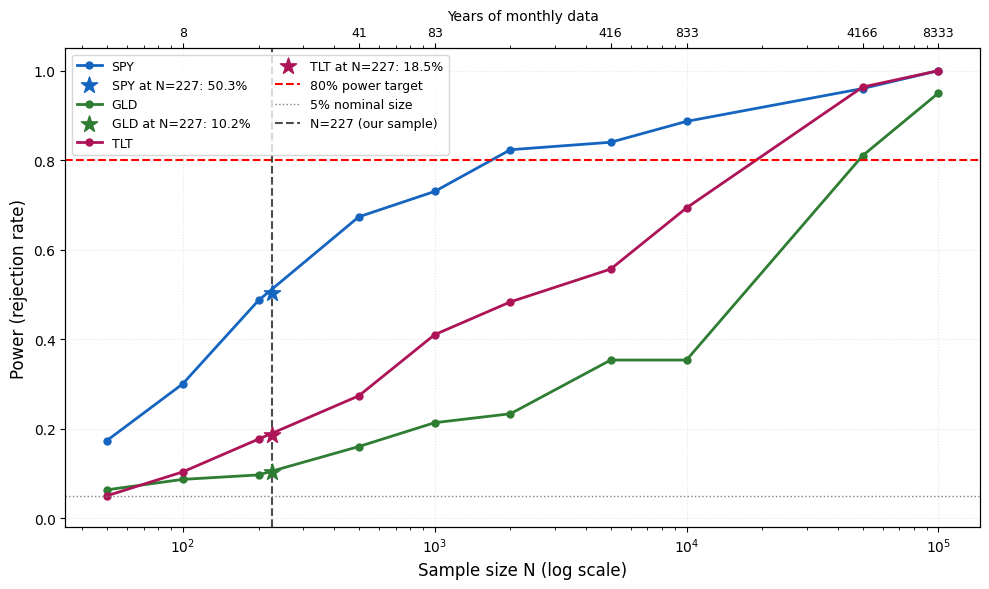

Saved to power_curves_assets.png


In [69]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

N_vals   = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000]
N_actual = 227
colors   = {'SPY': '#1565C0', 'GLD': '#2E7D32', 'TLT': '#AD1457'}

fig, ax = plt.subplots(figsize=(10, 6))

for ticker in ['SPY', 'GLD', 'TLT']:
    res    = asset_results[ticker]
    powers = res['powers']
    valid  = [np.isfinite(p) for p in powers]
    N_plot = [N for N, v in zip(N_vals, valid) if v]
    P_plot = [p for p, v in zip(powers, valid) if v]

    ax.plot(N_plot, P_plot, 'o-',
            color=colors[ticker], lw=2, ms=5, label=ticker)

    # Mark power at actual sample size
    p_at_N = float(np.interp(N_actual, N_vals, powers))
    ax.scatter(N_actual, p_at_N,
               color=colors[ticker], s=150, zorder=6,
               marker='*', label=f'{ticker} at N={N_actual}: {p_at_N:.1%}')

ax.axhline(0.80, color='red',   lw=1.5, ls='--', label='80% power target')
ax.axhline(0.05, color='grey',  lw=1.0, ls=':',  label='5% nominal size')
ax.axvline(N_actual, color='black', lw=1.5, ls='--',
           label=f'N={N_actual} (our sample)', alpha=0.7)

ax.set_xscale('log')
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Sample size N (log scale)', fontsize=12)
ax.set_ylabel('Power (rejection rate)', fontsize=12)
#ax.set_title('Power of Autocovariance Test for Stochastic Volatility\n'
#             'SPY, GLD and TLT — Monthly Returns (h = 21/252)\n'
#             '(★ marks estimated power at actual sample size N = 227)',
#             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, ls=':')

# Secondary x-axis — years of monthly data
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
tick_N    = [100, 500, 1000, 5000, 10000, 50000, 100000]
tick_labs = [f'{int(N/12)}' for N in tick_N]
ax2.set_xticks(tick_N)
ax2.set_xticklabels(tick_labs, fontsize=9)
ax2.set_xlabel('Years of monthly data', fontsize=10)

plt.tight_layout()
plt.savefig('power_curves_assets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to power_curves_assets.png")

In [68]:
print(f"\n{'Ticker':<8s}  {'κ':>8s}  {'θ':>7s}  {'σ_V':>6s}  "
      f"{'Power@227':>10s}  {'N for 80%':>12s}  {'Yrs monthly':>12s}")
print("-" * 68)

for ticker in ['SPY', 'GLD', 'TLT']:
    est    = asset_results[ticker]['est']
    powers = asset_results[ticker]['powers']
    p_227  = float(np.interp(N_actual, N_vals, powers))

    n_80 = None
    for i in range(len(powers)-1):
        if (np.isfinite(powers[i]) and np.isfinite(powers[i+1]) and
                powers[i] < 0.8 <= powers[i+1]):
            frac = (0.8-powers[i])/(powers[i+1]-powers[i])
            n_80 = int(N_vals[i] + frac*(N_vals[i+1]-N_vals[i]))
            break

    n80_str = f"{n_80:>12,}"       if n_80 else f"{'> 100,000':>12s}"
    yrs_str = f"{n_80//12:>10,} yrs" if n_80 else f"{'> 8,333':>10s} yrs"

    print(f"  {ticker:<6s}  {est['kappa']:>8.3f}  {est['theta']:>7.4f}  "
          f"{est['sigma_V']:>6.3f}  {p_227:>9.1%}  {n80_str}  {yrs_str}")


Ticker           κ        θ     σ_V   Power@227     N for 80%   Yrs monthly
--------------------------------------------------------------------
  SPY        0.146   0.0229   0.972      50.3%         1,750         145 yrs
  GLD        6.620   0.0326   2.000      10.2%        49,124       4,093 yrs
  TLT        4.153   0.0171   2.000      18.5%        25,802       2,150 yrs
